In [1]:
import sys
import os
current_dir = os.path.abspath('')
os.chdir(current_dir)
sys.path.append(os.path.join(current_dir,'..','..','code','BalancingControl'))

import two_stage_utils as tu
import inference as inf
import inference_utils as iu

torch threads 1
Running on device cpu
torch threads 1


In [2]:
import torch
import pyro

import pyro.distributions as dist

from scipy.io import loadmat
from scipy.stats import ttest_1samp, mannwhitneyu
import matplotlib.pylab as plt
import seaborn as sns
import pandas as pd
import glob
# import pickle
import jsonpickle as pickle
import json
import gc
from statannotations.Annotator import Annotator
import numpy as np

from scipy.stats import pearsonr
from statsmodels.stats.multitest import multipletests

In [3]:
results_folder = "results"
inference_folder = os.path.join(results_folder, "inference")

model_comp_folder = os.path.join(results_folder, "model_comparison")

mask_file_name = "mask.txt"
processed_data_folder = os.path.join("processed_data")
mask_file = os.path.join(processed_data_folder, mask_file_name)

processed_data_folder = os.path.join("processed_data")

statistics_folder = os.path.join(results_folder, "statistics")

scores_file_name = "scores.csv"
scores_file = os.path.join(statistics_folder, scores_file_name)

agent_data_fname = "data_formatted_for_agent.pkl"
agent_data_file = os.path.join(processed_data_folder, agent_data_fname)

non_fit_fname = "non_fit_file.txt"
non_fit_file = os.path.join(model_comp_folder, non_fit_fname)

In [4]:
trials =  272#number of trials
T = 3 #number of time steps in each trial
nb = 4 # number of bandits, ie second level rewards
ns = 3+nb #number of states
no = ns #number of observations
na = 2 #number of actions
npi = na**(T-1) #number of policies
nr = 2 #number of rewards
never_reward = ns-nb # states that dont generate rewards

# prob for invalid answer (e.g. no reply). Same frequency as in the real data
p_valid = 0.01

# make global parameter dict:
global_experiment_parameters = {"trials": trials, "T": T, "nb": nb, "ns": ns, "no": no, "na": na, "npi": npi, "nr": nr, "never_reward": never_reward, "p_invalid": p_valid}

In [5]:
#generating probability of observations in each state / unity matrix
A = torch.eye(no)


#state transition generative probability (matrix)
B = torch.zeros((ns, ns, na))
b1 = 0.7
nb1 = 1.-b1
b2 = 0.7
nb2 = 1.-b2

B[:,:,0] = torch.tensor([[  0,  0,  0,  0,  0,  0,  0,],
                         [ b1,  0,  0,  0,  0,  0,  0,],
                         [nb1,  0,  0,  0,  0,  0,  0,],
                         [  0,  1,  0,  1,  0,  0,  0,],
                         [  0,  0,  1,  0,  1,  0,  0,],
                         [  0,  0,  0,  0,  0,  1,  0,],
                         [  0,  0,  0,  0,  0,  0,  1,],])

B[:,:,1] = torch.tensor([[  0,  0,  0,  0,  0,  0,  0,],
                         [nb2,  0,  0,  0,  0,  0,  0,],
                         [ b2,  0,  0,  0,  0,  0,  0,],
                         [  0,  0,  0,  1,  0,  0,  0,],
                         [  0,  0,  0,  0,  1,  0,  0,],
                         [  0,  1,  0,  0,  0,  1,  0,],
                         [  0,  0,  1,  0,  0,  0,  1,],])

# add to parameter dict
global_experiment_parameters["A"] = A
global_experiment_parameters["B"] = B

In [6]:
def convert_data_for_agent(data):

    data_obs = torch.stack([torch.from_numpy(d["observations"]) for d in data], dim=-1)
    data_rew = torch.stack([torch.from_numpy(d["rewards"]) for d in data], dim=-1)
    data_act = torch.stack([torch.from_numpy(d["actions"]) for d in data], dim=-1)
    data_val = torch.cat([torch.from_numpy(d["valid"]) for d in data], dim=-1)
    data_ind = torch.stack([torch.from_numpy(d["subject"]) for d in data], dim=-1)

    structured_data = {"subject": data_ind, "observations": data_obs, "rewards": data_rew, "actions": data_act, "valid": data_val}

    return structured_data

In [7]:
with open(agent_data_file, 'r') as infile:
    loaded = json.load(infile)
full_data = pickle.decode(loaded)

n_agents = len(full_data)
print("n subjects", n_agents)

data = convert_data_for_agent(full_data)

print(data)

exp_mask = data["valid"]

n subjects 24
{'subject': tensor([[ 0,  1,  2,  ..., 21, 22, 23],
        [ 0,  1,  2,  ..., 21, 22, 23],
        [ 0,  1,  2,  ..., 21, 22, 23],
        ...,
        [ 0,  1,  2,  ..., 21, 22, 23],
        [ 0,  1,  2,  ..., 21, 22, 23],
        [ 0,  1,  2,  ..., 21, 22, 23]]), 'observations': tensor([[[ 0,  0,  0,  ...,  0,  0,  0],
         [-1,  1,  1,  ...,  1,  1,  1],
         [-3,  3,  3,  ...,  5,  5,  3]],

        [[ 0,  0,  0,  ...,  0,  0,  0],
         [ 1,  2,  2,  ...,  1,  2,  2],
         [ 3,  6,  6,  ...,  5,  6,  4]],

        [[ 0,  0,  0,  ...,  0,  0,  0],
         [ 1,  2,  1,  ...,  2,  2,  1],
         [ 3,  4,  5,  ...,  6,  6,  3]],

        ...,

        [[ 0,  0,  0,  ...,  0,  0,  0],
         [ 0,  1,  0,  ...,  0,  0,  0],
         [ 0,  5,  0,  ...,  0,  0,  0]],

        [[ 0,  0,  0,  ...,  0,  0,  0],
         [ 0,  1,  0,  ...,  0,  0,  0],
         [ 0,  3,  0,  ...,  0,  0,  0]],

        [[ 0,  0,  0,  ...,  0,  0,  0],
         [ 0,  1,  0,  

In [8]:
def load_BCC_results(learn_rewards, learn_habit, learn_cached, base_dir, global_experiment_parameters, valid, fname_base, num_steps, data, param_names, use_h=False):    

    # set up agent
    bayes_agent = tu.set_up_Bayesian_inference_agent(n_agents, learn_rewards, learn_habit, learn_cached, base_dir, 
                                                    global_experiment_parameters, data["valid"], remove_old=False, 
                                                    use_h=use_h)

    print('analyzing '+str(n_agents)+' data sets')

    resample = False

    # set up inference
    inferrer = inf.GeneralGroupInference(bayes_agent, data)

    fname_str = fname_base + str(num_steps)+'_'+str(n_agents)+'agents'

    inferrer.load_parameters(os.path.join(base_dir, fname_str+"_parameter.save"))

    inferrer.load_elbo(os.path.join(base_dir, fname_str+"_elbo.save"))

    if resample:
        mean_df, sample_df, locs_sample_df = iu.sample_posterior(inferrer, param_names, fname_str, base_dir) 
    else:
        mean_df, sample_df, locs_sample_df = iu.load_samples(base_dir, fname_str) 

    return mean_df, sample_df, locs_sample_df

In [9]:
# def load_MFMB_results(use_orig, learn_prior, use_p, restrict_alpha, max_dt, base_dir, global_experiment_parameters, valid, fname_base, num_steps, data, param_names):    

#     # set up agent
#     mfmb_agent = tu.set_up_mbmf_inference_agent(n_agents, learn_prior, use_orig, use_p, restrict_alpha, max_dt, 0, base_dir, global_experiment_parameters, valid, remove_old=False)

#     print('analyzing '+str(n_agents)+' data sets')

#     resample = False

#     # set up inference
#     inferrer = inf.GeneralGroupInference(mfmb_agent, data)

#     fname_str = fname_base + str(num_steps)+'_'+str(n_agents)+'agents'

#     inferrer.load_parameters(os.path.join(base_dir, fname_str+"_parameter.save"))

#     inferrer.load_elbo(os.path.join(base_dir, fname_str+"_elbo.save"))

#     if resample:
#         mean_df, sample_df, locs_sample_df = iu.sample_posterior(inferrer, param_names, fname_str, base_dir) 
#     else:
#         mean_df, sample_df, locs_sample_df = iu.load_samples(base_dir, fname_str) 

#     return mean_df, sample_df, locs_sample_df

In [10]:
def calculate_log_likelihood(data, agent, locs_df, npars, trials, T):

    # question: what do with nan trials? If I ignore them, they will decrease the likelihood and make subject seem to fit better. If I make them uniform, itll decrease by a lot?
    # this is the likelihood of the average parameter

    n_agents = data["actions"].shape[-1]
    log_like = torch.zeros(n_agents).detach()
    
    locs_list = []
    for k in range(npars):
        locs_subs = []
        for i in range(n_agents):
            locs_subs.append(locs_df[locs_df["subject"]==i]["locs"+str(k)].mean())
        locs_list.append(torch.tensor(locs_subs).float())

    locs = torch.stack(locs_list, dim=-1).detach()
    
    assert(locs.shape[0]==n_agents)

    agent.reset(locs)

    for tau in pyro.markov(range(trials)):
        for t in range(T):

            if t==0:
                prev_response = None
                context = None
            else:
                prev_response = data["actions"][tau, t-1]
                context = None

            observation = data["observations"][tau, t]

            reward = data["rewards"][tau, t]

            agent.update_beliefs(tau, t, observation, reward, prev_response, context)

            if t < T-1:

                probs = agent.perception.posterior_actions[-1]
                if torch.any(torch.isnan(probs)):
                    print(probs)
                    #print(param_dict)
                    print(tau,t)

                curr_response = data["actions"][tau, t]*data["valid"][tau].long()

                one_hot_responses = torch.nn.functional.one_hot(curr_response, num_classes=2).permute((1,0))[:,None,:].float()

                likes = (probs * one_hot_responses).sum(dim=0)[0]

                masked_probs = torch.where(data["valid"][tau], likes, torch.tensor([0.5]))

                log_like += torch.log(masked_probs)

    return log_like.clone().detach()
    

In [11]:
def calculate_BIC(data, agent, locs_df, npars, trials, T):

    # use bic to circumvent the number of trials problem

    n_agents = data["actions"].shape[-1]
    BIC = torch.zeros(n_agents).detach()
    
    locs_list = []
    for k in range(npars):
        locs_subs = []
        for i in range(n_agents):
            locs_subs.append(locs_df[locs_df["subject"]==i]["locs"+str(k)].mean())
        locs_list.append(torch.tensor(locs_subs).float())

    locs = torch.stack(locs_list, dim=-1).detach()
    
    assert(locs.shape[0]==n_agents)

    agent.reset(locs)

    for tau in pyro.markov(range(trials)):
        for t in range(T):

            if t==0:
                prev_response = None
                context = None
            else:
                prev_response = data["actions"][tau, t-1]
                context = None

            observation = data["observations"][tau, t]

            reward = data["rewards"][tau, t]

            agent.update_beliefs(tau, t, observation, reward, prev_response, context)

            if t < T-1:

                probs = agent.perception.posterior_actions[-1]
                if torch.any(torch.isnan(probs)):
                    print(probs)
                    #print(param_dict)
                    print(tau,t)

                curr_response = data["actions"][tau, t]*data["valid"][tau].long()

                one_hot_responses = torch.nn.functional.one_hot(curr_response, num_classes=2).permute((1,0))[:,None,:].float()

                likes = (probs * one_hot_responses).sum(dim=0)[0]

                masked_probs = torch.where(data["valid"][tau], likes, torch.tensor(0.5))

                print(masked_probs.shape)

                BIC -= 2*torch.log(masked_probs)

    # question: is it noraml that the first term of the BIC (k*ln(n)) is much smaller than the second (-2*ln(L))?
    BIC += npars*torch.log(data["valid"].sum(axis=0))

    return BIC.clone().detach()
    

In [12]:
def calculate_lppd(data, agent, locs_df, npars, trials, T, max_samples=-1):

    # question: what do with nan trials? If I ignore them, they will decrease the likelihood and make subject seem to fit better. If I make them uniform, itll decrease by a lot?
    # Eqs (4,5) from here:
    # http://www.stat.columbia.edu/~gelman/research/published/waic_understand3.pdf
    # this is the average likelihood

    n_agents = data["actions"].shape[-1]
    
    locs_list = []
    for k in range(npars):
        locs_subs = []
        for i in range(n_agents):
            locs_subs.append(torch.tensor(locs_df[locs_df["subject"]==i]["locs"+str(k)].values[:max_samples]).float())
        locs_list.append(torch.stack(locs_subs, dim=-1))

    locs = torch.stack(locs_list, dim=-1).detach()

    n_samples = locs.shape[0]

    likelihoods = []

    agent.reset(locs)

    for tau in pyro.markov(range(trials)):
        for t in range(T):

            if t==0:
                prev_response = None
                context = None
            else:
                prev_response = data["actions"][tau, t-1]
                context = None

            observation = data["observations"][tau, t]

            reward = data["rewards"][tau, t]

            agent.update_beliefs(tau, t, observation, reward, prev_response, context)

            if t < T-1:

                probs = agent.perception.posterior_actions[-1]
                #print("probs", probs.shape)
                if torch.any(torch.isnan(probs)):
                    print(probs)
                    #print(param_dict)
                    print(tau,t)

                curr_response = data["actions"][tau, t]*data["valid"][tau].long()

                one_hot_responses = torch.nn.functional.one_hot(curr_response, num_classes=2).permute((1,0))[:,None,:].float()

                likes = (probs * one_hot_responses).sum(dim=0)

                masked_probs = torch.where(data["valid"][tau], likes, torch.tensor([0.5]))
                #print("masked probs", masked_probs.shape)

                likelihoods.append(masked_probs)

                #print(tau,t)

    mean_like = torch.stack(likelihoods, dim=0).detach()
    # print("mean like stacked", mean_like.shape)
    # print(mean_like)

    mean_like = mean_like.sum(dim=-2).detach() / n_samples
    # print("mean like summed", mean_like.shape)
    # print(mean_like)

    mean_log_like = torch.log(mean_like).sum(dim=0).detach()

    #print(mean_log_like)
    # print("mean log like", mean_log_like.shape)
    # print(mean_log_like)

    return mean_log_like.clone().detach()
    

In [13]:
def calculate_waic(data, agent, locs_df, npars, trials, T, max_samples=-1):

    # question: what do with nan trials? If I ignore them, they will decrease the likelihood and make subject seem to fit better. If I make them uniform, itll decrease by a lot?
    # Eqs (12,13) from here:
    # http://www.stat.columbia.edu/~gelman/research/published/waic_understand3.pdf
    # this is the average WAIC
    # are the larger number of params handled correctly?

    n_agents = data["actions"].shape[-1]
    
    locs_list = []
    for k in range(npars):
        locs_subs = []
        for i in range(n_agents):
            locs_subs.append(torch.tensor(locs_df[locs_df["subject"]==i]["locs"+str(k)].values[:max_samples]).float())
        locs_list.append(torch.stack(locs_subs, dim=-1))

    locs = torch.stack(locs_list, dim=-1).detach()

    n_samples = locs.shape[0]

    likelihoods = []

    agent.reset(locs)

    for tau in pyro.markov(range(trials)):
        for t in range(T):

            if t==0:
                prev_response = None
                context = None
            else:
                prev_response = data["actions"][tau, t-1]
                context = None

            observation = data["observations"][tau, t]

            reward = data["rewards"][tau, t]

            agent.update_beliefs(tau, t, observation, reward, prev_response, context)

            if t < T-1:

                probs = agent.perception.posterior_actions[-1]
                #print("probs", probs.shape)
                if torch.any(torch.isnan(probs)):
                    print(probs)
                    #print(param_dict)
                    print(tau,t)

                curr_response = data["actions"][tau, t]*data["valid"][tau].long()

                one_hot_responses = torch.nn.functional.one_hot(curr_response, num_classes=2).permute((1,0))[:,None,:].float()

                likes = (probs * one_hot_responses).sum(dim=0)

                masked_probs = torch.where(data["valid"][tau], likes, torch.tensor([0.5]))
                #print("masked probs", masked_probs.shape)

                likelihoods.append(masked_probs.clone().detach())

                #print(tau,t)



    mean_like = torch.stack(likelihoods, dim=0).detach()
    # print("mean like stacked", mean_like.shape)
    # print(mean_like)

    mean_like_samples = mean_like.sum(dim=-2).detach() / n_samples
    # print("mean like summed", mean_like.shape)
    # print(mean_like)

    lppd = torch.log(mean_like_samples).sum(dim=0).detach()
    # print("mean log like", mean_log_like.shape)
    # print(mean_log_like)

    mean_log_like_samples = torch.log(mean_like.sum(dim=-2)).detach() / n_samples

    V_s = ((torch.log(mean_like) - mean_log_like_samples[:,None,:])**2).sum(dim=-2) / (n_samples-1)

    p_waic = V_s.sum(dim=0).detach()

    ellp_waic = lppd - p_waic

    # text says it needs to be -2 * eq 13.
    # minus is required to make lower better, and the 2 converts it to variance scale

    return ellp_waic.clone().detach()
    

In [14]:
def predictive_accuracy_mean_param(data, agent, locs_df, npars, trials, T):

    n_agents = data["actions"].shape[-1]

    predicted_accuracy = torch.zeros(n_agents).detach()
    
    locs_list = []
    for k in range(npars):
        locs_subs = []
        for i in range(n_agents):
            locs_subs.append(locs_df[locs_df["subject"]==i]["locs"+str(k)].mean())
        locs_list.append(torch.tensor(locs_subs).float())

    locs = torch.stack(locs_list, dim=-1).detach()
    
    assert(locs.shape[0]==n_agents)

    agent.reset(locs)

    num_valid_responses = torch.zeros(data["actions"].shape[-1]).detach()

    for tau in pyro.markov(range(trials)):
        for t in range(T):

            if t==0:
                prev_response = None
                context = None
            else:
                prev_response = data["actions"][tau, t-1]
                context = None

            observation = data["observations"][tau, t]

            reward = data["rewards"][tau, t]

            agent.update_beliefs(tau, t, observation, reward, prev_response, context)

            if t < T-1:
                #print(tau,t)

                probs = agent.perception.posterior_actions[-1]
                if torch.any(torch.isnan(probs)):
                    print(probs)
                    #print(param_dict)
                    print(tau,t)

                curr_response = data["actions"][tau, t]#*data["valid"][tau].long()
                #print(curr_response)

                predicted_response = torch.argmax(probs, dim=0)[0]

                #print(probs)

                #print(predicted_response)

                correct_response_predicted = (curr_response == predicted_response).int()

                #print(correct_response_predicted)

                predicted_accuracy += correct_response_predicted

                num_valid_responses += data["valid"][tau]

                #print(num_valid_responses)


    corrected_predicted_accuracy = predicted_accuracy / num_valid_responses

    return corrected_predicted_accuracy.clone().detach()

In [15]:
def calculate_exceedance_prob(measure, n_exc_samples=500):
    
    p_model = torch.nn.functional.softmax(measure, dim=-1).detach()

    print("p model mean according to measure", p_model.mean(dim=0))

    dirichlet_counts = p_model.sum(dim=0).detach()

    model_prob_dirichlet = dist.Dirichlet(dirichlet_counts)

    n_exc_samples = 500

    dir_samples = model_prob_dirichlet.sample(sample_shape=torch.tensor([n_exc_samples]))

    avg_best_model = dir_samples.mean(dim=0).argmax()

    best_model = dir_samples.argmax(dim=1)

    exc_prob = (best_model == avg_best_model).sum()/n_exc_samples

    print("best model:", avg_best_model, "exceedance prob", exc_prob)

    significant_best_model = ttest_1samp(dir_samples[:,avg_best_model], 1./measure.shape[-1], alternative="greater")

    print("is significantly different from uniform?", significant_best_model)

    return exc_prob.clone().detach(), avg_best_model.clone().detach()

### make plot helper function

In [16]:
def plot_correlations(plot_df, x_vars_of_interest, y_vars_of_interest):

    if set(x_vars_of_interest) == set(y_vars_of_interest):
        square = True
        vars_of_interest = x_vars_of_interest
    else:
        square = False
        vars_of_interest = x_vars_of_interest+y_vars_of_interest
    rho = plot_df[vars_of_interest].corr()
    pval = plot_df[vars_of_interest].corr(method=lambda x, y: pearsonr(x, y)[1]) - np.eye(*rho.shape)
    reject, pval_corrected, alphaS, alphaB = multipletests(pval, method='bonferroni')

    if square:
        mask = np.triu(np.ones_like(rho, dtype=bool), k=1)
    else:
        mask = np.zeros_like(rho.loc[x_vars_of_interest,y_vars_of_interest], dtype=bool)

    plt.figure()

    alpha_plot = np.where(pval.loc[x_vars_of_interest,y_vars_of_interest]<0.05, 1, 0.1)
    # sns.set(font_scale=1.2)
    g = sns.heatmap(rho.loc[x_vars_of_interest,y_vars_of_interest], annot=rho.loc[x_vars_of_interest,y_vars_of_interest], fmt='.2f', cmap='Spectral_r', alpha=alpha_plot, 
                # palettes: crest, icefire, vlag, Greys, RdGy, RdBu, etc etc, and add _r for reversed
                vmin=-1, vmax=1, mask=mask, annot_kws={"size": 12})#, ax=ax)
    g.set_xticklabels(g.get_xmajorticklabels(), fontsize = 12)
    g.set_yticklabels(g.get_ymajorticklabels(), fontsize = 12)
    cbar = g.collections[0].colorbar
    cbar.ax.tick_params(labelsize=12)

    plt.show()

### Load BCC2 planning results, and plot correlations between inferred parameters

BCC_2pars_plan_NO_context
BCC_2pars_plan_NO_context_inference_
2
analyzing 24 data sets
2


/home/sarah/src/TwoStageStrategies/FeherDaSilva_data/magic_carpet/../../code/BalancingControl/perception.py:136: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3683.)
  self.big_trans_matrix = ar.stack([ar.stack([generative_model_states[:,:,policies[pi,t]] for pi in range(self.npi)]) for t in range(self.T-1)]).T.to(device)
/home/sarah/python_venvs/TwoStageStrategies/lib/python3.13/site-packages/pyro/params/param_store.py:334: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://g

<Figure size 640x480 with 0 Axes>

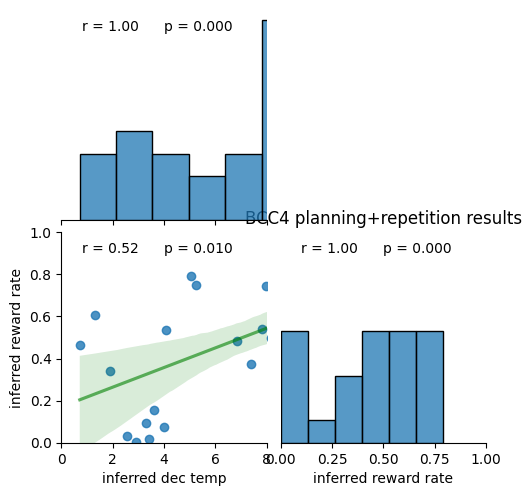

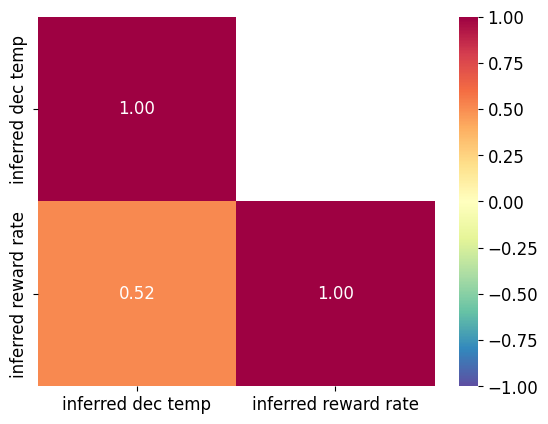

In [17]:
# BCC2 planning analysis

learn_rewards = True
learn_habit = False
use_h = False
learn_cached = False

param_names = []
param_ranges = []

prefix = "BCC"
model_name = "Bayesian prior-based contextual control model"
n_pars = 0
agnt_str = ""

if learn_rewards:
    n_pars += 2
    param_names += ["dec temp", "reward rate"]
    param_ranges += [[0,8], [0,1]]
    agnt_str += "_plan"

if learn_habit:
    # infer_h = True
    # infer_policy_rate = True 
    n_pars += 2
    agnt_str += "_habit"
    param_names += ["habitual tendency", "policy rate"]
    if use_h:
        agnt_str += "_h"
        param_ranges += [[0,1], [0,1]]
    else:
        agnt_str += "_weight"
        param_ranges += [[0,8], [0,1]]
# else:
#     infer_h = False
#     infer_policy_rate = False

if learn_cached:
    n_pars += 2
    param_names += ["cached weight", "cached rate"]
    param_ranges += [[0,8], [0,1]]
    agnt_str += "_cached"

assert n_pars > 0, "please turn any part of the agent on, it cannot run without any learning or inference."

# choose max decision temperature for numerical stability
max_dt = 6

BCC2_param_names = param_names.copy()
BCC2_param_ranges = param_ranges.copy()

# prepare for saving results
# make base filename and folder string
agent_type = prefix+"_"+str(n_pars)+"pars"+agnt_str+"_NO_context"
print(agent_type)

# prepare for saving results
# make base filename and folder string
fname_base = agent_type+"_inference_"
print(fname_base)
# define folder where we want to save data
base_dir = os.path.join(inference_folder,fname_base[:-1])

# make directory if it doesnt exist
if fname_base[:-1] not in os.listdir(inference_folder):
    os.mkdir(base_dir)

num_steps = 600

BCC2_mean_df, BCC2_sample_df, BCC2_locs_df = load_BCC_results(learn_rewards, learn_habit, learn_cached, base_dir, global_experiment_parameters, exp_mask, fname_base, num_steps, data, param_names, use_h=False)

BCC2_agent = tu.set_up_Bayesian_inference_agent(n_agents, learn_rewards, learn_habit, learn_cached, base_dir, global_experiment_parameters, data["valid"], remove_old=False, use_h=use_h)

BCC2_params = torch.stack([torch.tensor(BCC2_mean_df["inferred "+name]) for name in BCC2_param_names], dim=-1)

# param_plot_ranges = [[-0.25,1.25], [-0.25,1.25], [0,10]]

plt.figure()
vars_of_interest = ["inferred "+name for name in param_names]
f = sns.pairplot(data=BCC2_mean_df, kind='reg', diag_kind="hist", corner=True,
                    plot_kws={'line_kws': {'color': 'green', 'alpha': 0.6}},
                    x_vars=vars_of_interest, y_vars=vars_of_interest)
f.map(tu.annot_corrfunc)
for p, p_range in enumerate(param_ranges):
    f.axes[n_pars-1,p].set_xlim(p_range)
    f.axes[p,0].set_ylim(p_range)
plt.title("BCC4 planning+repetition results")
#plt.savefig(os.path.join(base_dir, fname_str+"_pairplot_means_inferred_corr.svg"))
plt.show()

plot_correlations(BCC2_mean_df, vars_of_interest, vars_of_interest)


In [18]:
# calculate agent log likelihood using mean params

BCC2_log_like = -calculate_log_likelihood(data, BCC2_agent, BCC2_locs_df, len(BCC2_param_names), global_experiment_parameters["trials"], global_experiment_parameters["T"])

BCC2_BIC = calculate_BIC(data, BCC2_agent, BCC2_locs_df, len(BCC2_param_names), global_experiment_parameters["trials"], global_experiment_parameters["T"])

BCC2_lppd = -calculate_lppd(data, BCC2_agent, BCC2_locs_df, len(BCC2_param_names), 
                            global_experiment_parameters["trials"], global_experiment_parameters["T"], max_samples=50)

BCC2_WAIC = -calculate_waic(data, BCC2_agent, BCC2_locs_df, len(BCC2_param_names), 
                            global_experiment_parameters["trials"], global_experiment_parameters["T"], max_samples=50)

measures_df = pd.DataFrame({"subject": list(range(n_agents)), "measure": BCC2_log_like, "type": ["log likelihood"]*n_agents, "model": ["BCC2"]*n_agents})
measures_df = pd.concat([measures_df, pd.DataFrame({"subject": list(range(n_agents)), "measure": BCC2_lppd, "type": ["lppd"]*n_agents, "model": ["BCC2"]*n_agents})])
measures_df = pd.concat([measures_df, pd.DataFrame({"subject": list(range(n_agents)), "measure": BCC2_BIC, "type": ["BIC"]*n_agents, "model": ["BCC2"]*n_agents})])
measures_df = pd.concat([measures_df, pd.DataFrame({"subject": list(range(n_agents)), "measure": BCC2_WAIC, "type": ["WAIC"]*n_agents, "model": ["BCC2"]*n_agents})])

print("BCC2 log like", BCC2_log_like.mean())

print("BCC2 BIC", BCC2_BIC.mean())

print("BCC2 lppd", BCC2_lppd.mean())

gc.collect()

torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24

1241

### Load BCC4 planning+repetition results, and plot correlations between inferred parameters

BCC_4pars_plan_habit_weight_NO_context
BCC_4pars_plan_habit_weight_NO_context_inference_
4
analyzing 24 data sets
4


/home/sarah/python_venvs/TwoStageStrategies/lib/python3.13/site-packages/pyro/params/param_store.py:334: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(inp

<Figure size 640x480 with 0 Axes>

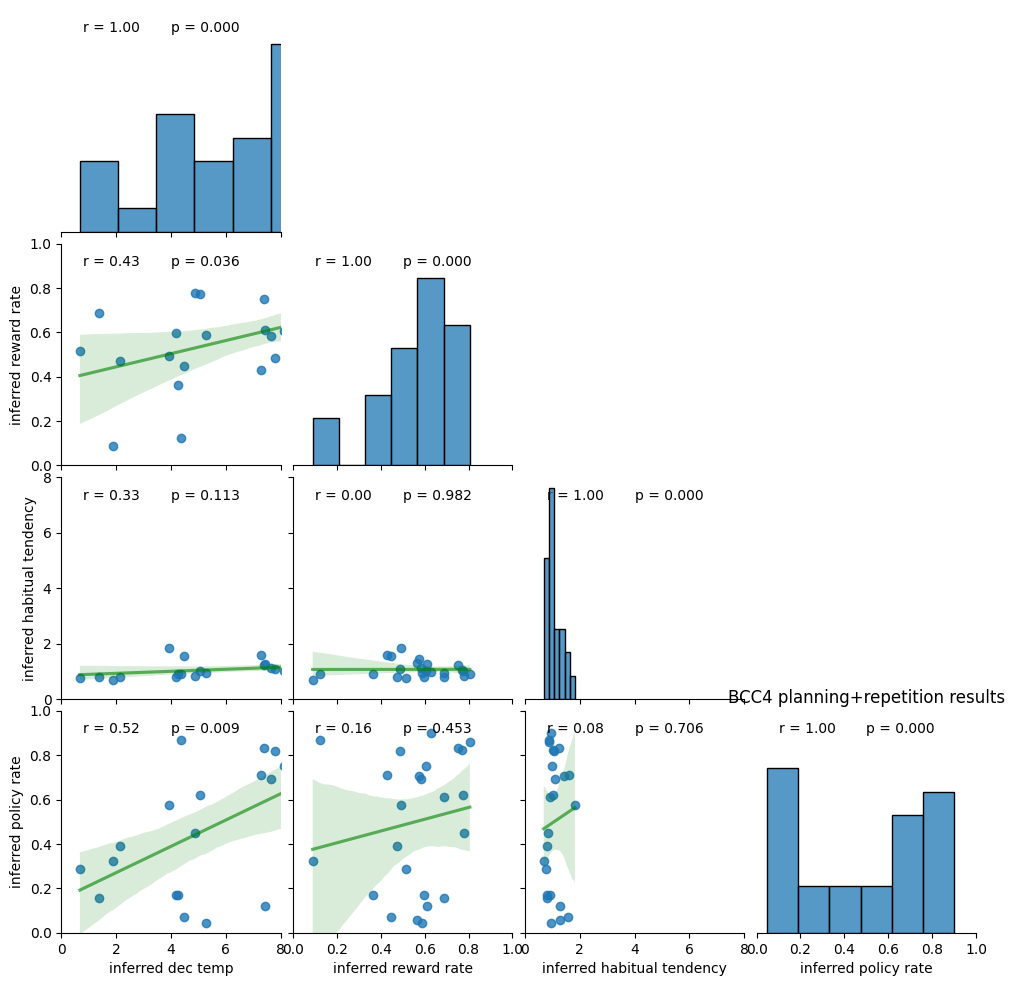

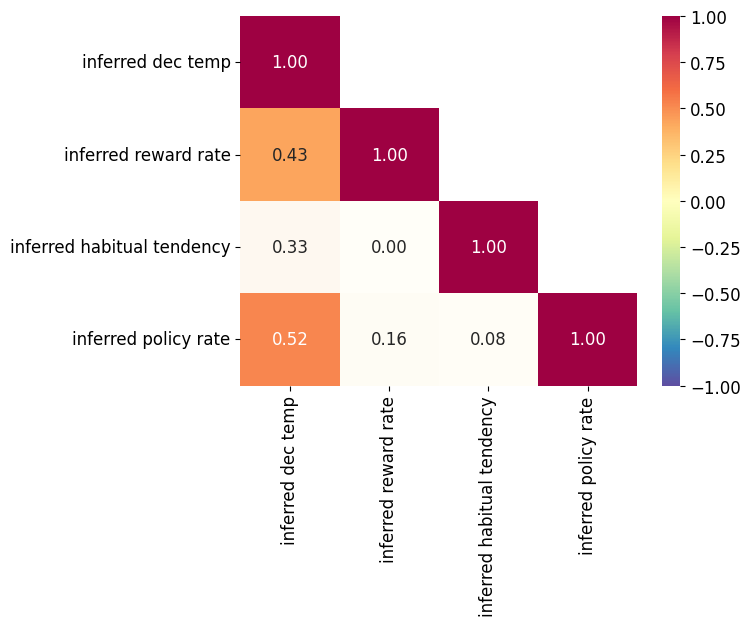

In [19]:
# BCC4 planning repetition analysis

learn_rewards = True
learn_habit = True
use_h = False
learn_cached = False

param_names = []
param_ranges = []

prefix = "BCC"
model_name = "Bayesian prior-based contextual control model"
n_pars = 0
agnt_str = ""

if learn_rewards:
    n_pars += 2
    param_names += ["dec temp", "reward rate"]
    param_ranges += [[0,8], [0,1]]
    agnt_str += "_plan"

if learn_habit:
    # infer_h = True
    # infer_policy_rate = True 
    n_pars += 2
    agnt_str += "_habit"
    param_names += ["habitual tendency", "policy rate"]
    if use_h:
        agnt_str += "_h"
        param_ranges += [[0,1], [0,1]]
    else:
        agnt_str += "_weight"
        param_ranges += [[0,8], [0,1]]
# else:
#     infer_h = False
#     infer_policy_rate = False

if learn_cached:
    n_pars += 2
    param_names += ["cached weight", "cached rate"]
    param_ranges += [[0,8], [0,1]]
    agnt_str += "_cached"

assert n_pars > 0, "please turn any part of the agent on, it cannot run without any learning or inference."

# choose max decision temperature for numerical stability
max_dt = 6

BCC4_p_r_param_names = param_names.copy()
BCC4_p_r_param_ranges = param_ranges.copy()

# prepare for saving results
# make base filename and folder string
agent_type = prefix+"_"+str(n_pars)+"pars"+agnt_str+"_NO_context"
print(agent_type)

# prepare for saving results
# make base filename and folder string
fname_base = agent_type+"_inference_"
print(fname_base)
# define folder where we want to save data
base_dir = os.path.join(inference_folder,fname_base[:-1])

# make directory if it doesnt exist
if fname_base[:-1] not in os.listdir(inference_folder):
    os.mkdir(base_dir)

num_steps = 600

BCC4_p_r_mean_df, BCC4_p_r_sample_df, BCC4_p_r_locs_df = load_BCC_results(learn_rewards, learn_habit, learn_cached, base_dir, global_experiment_parameters, exp_mask, fname_base, num_steps, data, param_names, use_h=False)

BCC4_p_r_agent = tu.set_up_Bayesian_inference_agent(n_agents, learn_rewards, learn_habit, learn_cached, base_dir, global_experiment_parameters, data["valid"], remove_old=False, use_h=use_h)

BCC4_p_r_params = torch.stack([torch.tensor(BCC4_p_r_mean_df["inferred "+name]) for name in BCC4_p_r_param_names], dim=-1)

# param_plot_ranges = [[-0.25,1.25], [-0.25,1.25], [0,10]]

plt.figure()
vars_of_interest = ["inferred "+name for name in param_names]
f = sns.pairplot(data=BCC4_p_r_mean_df, kind='reg', diag_kind="hist", corner=True,
                    plot_kws={'line_kws': {'color': 'green', 'alpha': 0.6}},
                    x_vars=vars_of_interest, y_vars=vars_of_interest)
f.map(tu.annot_corrfunc)
for p, p_range in enumerate(param_ranges):
    f.axes[n_pars-1,p].set_xlim(p_range)
    f.axes[p,0].set_ylim(p_range)
plt.title("BCC4 planning+repetition results")
#plt.savefig(os.path.join(base_dir, fname_str+"_pairplot_means_inferred_corr.svg"))
plt.show()

plot_correlations(BCC4_p_r_mean_df, vars_of_interest, vars_of_interest)


In [20]:
# calculate agent log likelihood using mean params

BCC4_p_r_log_like = -calculate_log_likelihood(data, BCC4_p_r_agent, BCC4_p_r_locs_df, len(BCC4_p_r_param_names), global_experiment_parameters["trials"], global_experiment_parameters["T"])

BCC4_p_r_BIC = calculate_BIC(data, BCC4_p_r_agent, BCC4_p_r_locs_df, len(BCC4_p_r_param_names), global_experiment_parameters["trials"], global_experiment_parameters["T"])

BCC4_p_r_lppd = -calculate_lppd(data, BCC4_p_r_agent, BCC4_p_r_locs_df, len(BCC4_p_r_param_names), 
                            global_experiment_parameters["trials"], global_experiment_parameters["T"], max_samples=50)

BCC4_p_r_WAIC = -calculate_waic(data, BCC4_p_r_agent, BCC4_p_r_locs_df, len(BCC4_p_r_param_names), 
                            global_experiment_parameters["trials"], global_experiment_parameters["T"], max_samples=50)

measures_df = pd.concat([measures_df, pd.DataFrame({"subject": list(range(n_agents)), "measure": BCC4_p_r_log_like, "type": ["log likelihood"]*n_agents, "model": ["BCC4_p_r"]*n_agents})])
measures_df = pd.concat([measures_df, pd.DataFrame({"subject": list(range(n_agents)), "measure": BCC4_p_r_lppd, "type": ["lppd"]*n_agents, "model": ["BCC4_p_r"]*n_agents})])
measures_df = pd.concat([measures_df, pd.DataFrame({"subject": list(range(n_agents)), "measure": BCC4_p_r_BIC, "type": ["BIC"]*n_agents, "model": ["BCC4_p_r"]*n_agents})])
measures_df = pd.concat([measures_df, pd.DataFrame({"subject": list(range(n_agents)), "measure": BCC4_p_r_WAIC, "type": ["WAIC"]*n_agents, "model": ["BCC4_p_r"]*n_agents})])

print("BCC4_p_r log like", BCC4_p_r_log_like.mean())

print("BCC4_p_r BIC", BCC4_p_r_BIC.mean())

print("BCC4_p_r lppd", BCC4_p_r_lppd.mean())

gc.collect()

torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24

1717

### Load BCC4 planning+cached results, and plot correlations between inferred parameters

BCC_4pars_plan_cached_NO_context
BCC_4pars_plan_cached_NO_context_inference_
4
analyzing 24 data sets
4


/home/sarah/python_venvs/TwoStageStrategies/lib/python3.13/site-packages/pyro/params/param_store.py:334: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(inp

<Figure size 640x480 with 0 Axes>

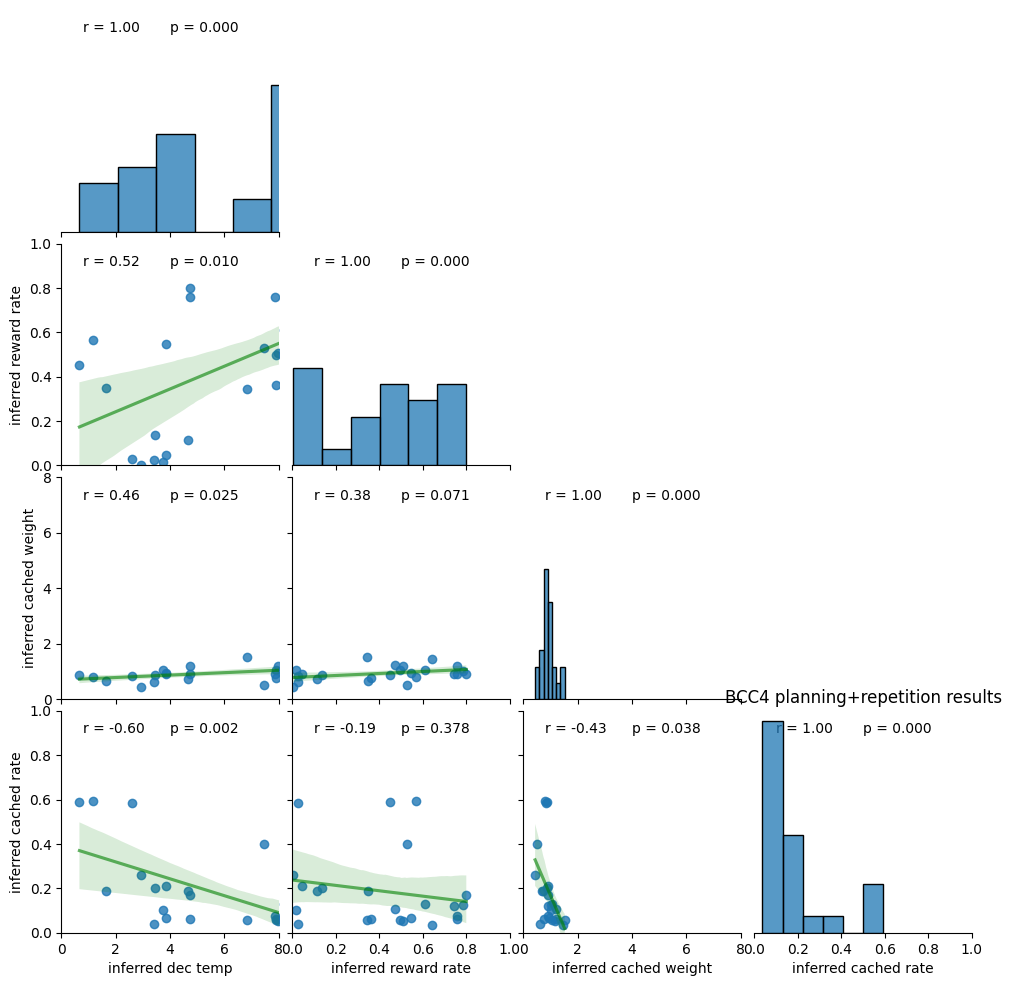

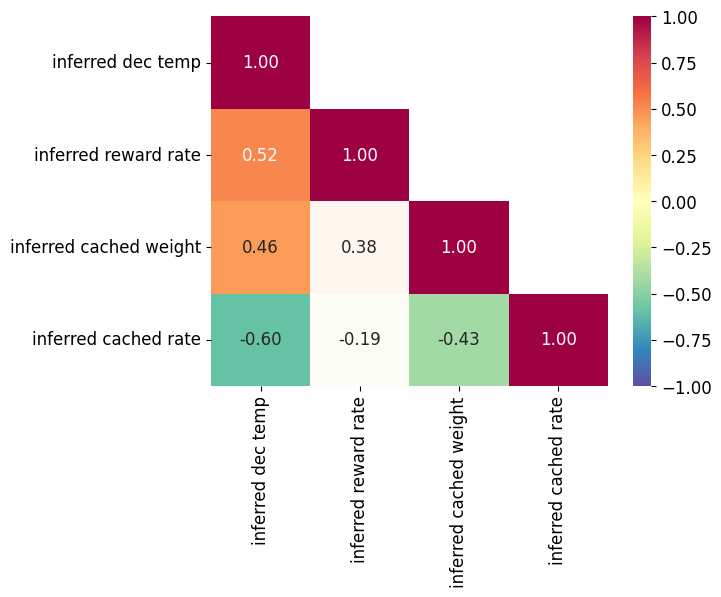

In [21]:
# BCC4 planning cached analysis

learn_rewards = True
learn_habit = False
use_h = False
learn_cached = True

param_names = []
param_ranges = []

prefix = "BCC"
model_name = "Bayesian prior-based contextual control model"
n_pars = 0
agnt_str = ""

if learn_rewards:
    n_pars += 2
    param_names += ["dec temp", "reward rate"]
    param_ranges += [[0,8], [0,1]]
    agnt_str += "_plan"

if learn_habit:
    # infer_h = True
    # infer_policy_rate = True 
    n_pars += 2
    agnt_str += "_habit"
    param_names += ["habitual tendency", "policy rate"]
    if use_h:
        agnt_str += "_h"
        param_ranges += [[0,1], [0,1]]
    else:
        agnt_str += "_weight"
        param_ranges += [[0,8], [0,1]]
# else:
#     infer_h = False
#     infer_policy_rate = False

if learn_cached:
    n_pars += 2
    param_names += ["cached weight", "cached rate"]
    param_ranges += [[0,8], [0,1]]
    agnt_str += "_cached"

assert n_pars > 0, "please turn any part of the agent on, it cannot run without any learning or inference."

# choose max decision temperature for numerical stability
max_dt = 6

BCC4_p_c_param_names = param_names.copy()
BCC4_p_c_param_ranges = param_ranges.copy()

# prepare for saving results
# make base filename and folder string
agent_type = prefix+"_"+str(n_pars)+"pars"+agnt_str+"_NO_context"
print(agent_type)

# prepare for saving results
# make base filename and folder string
fname_base = agent_type+"_inference_"
print(fname_base)
# define folder where we want to save data
base_dir = os.path.join(inference_folder,fname_base[:-1])

# make directory if it doesnt exist
if fname_base[:-1] not in os.listdir(inference_folder):
    os.mkdir(base_dir)

num_steps = 600

BCC4_p_c_mean_df, BCC4_p_c_sample_df, BCC4_p_c_locs_df = load_BCC_results(learn_rewards, learn_habit, learn_cached, base_dir, global_experiment_parameters, exp_mask, fname_base, num_steps, data, param_names, use_h=False)

BCC4_p_c_agent = tu.set_up_Bayesian_inference_agent(n_agents, learn_rewards, learn_habit, learn_cached, base_dir, global_experiment_parameters, data["valid"], remove_old=False, use_h=use_h)

BCC4_p_c_params = torch.stack([torch.tensor(BCC4_p_c_mean_df["inferred "+name]) for name in BCC4_p_c_param_names], dim=-1)

# param_plot_ranges = [[-0.25,1.25], [-0.25,1.25], [0,10]]

plt.figure()
vars_of_interest = ["inferred "+name for name in param_names]
f = sns.pairplot(data=BCC4_p_c_mean_df, kind='reg', diag_kind="hist", corner=True,
                    plot_kws={'line_kws': {'color': 'green', 'alpha': 0.6}},
                    x_vars=vars_of_interest, y_vars=vars_of_interest)
f.map(tu.annot_corrfunc)
for p, p_range in enumerate(param_ranges):
    f.axes[n_pars-1,p].set_xlim(p_range)
    f.axes[p,0].set_ylim(p_range)
plt.title("BCC4 planning+repetition results")
#plt.savefig(os.path.join(base_dir, fname_str+"_pairplot_means_inferred_corr.svg"))
plt.show()


plot_correlations(BCC4_p_c_mean_df, vars_of_interest, vars_of_interest)

In [22]:
# calculate agent log likelihood using mean params

BCC4_p_c_log_like = -calculate_log_likelihood(data, BCC4_p_c_agent, BCC4_p_c_locs_df, len(BCC4_p_c_param_names), global_experiment_parameters["trials"], global_experiment_parameters["T"])

BCC4_p_c_BIC = calculate_BIC(data, BCC4_p_c_agent, BCC4_p_c_locs_df, len(BCC4_p_c_param_names), global_experiment_parameters["trials"], global_experiment_parameters["T"])

BCC4_p_c_lppd = -calculate_lppd(data, BCC4_p_c_agent, BCC4_p_c_locs_df, len(BCC4_p_c_param_names), 
                            global_experiment_parameters["trials"], global_experiment_parameters["T"], max_samples=50)

BCC4_p_c_WAIC = -calculate_waic(data, BCC4_p_c_agent, BCC4_p_c_locs_df, len(BCC4_p_c_param_names), 
                            global_experiment_parameters["trials"], global_experiment_parameters["T"], max_samples=50)

measures_df = pd.concat([measures_df, pd.DataFrame({"subject": list(range(n_agents)), "measure": BCC4_p_c_log_like, "type": ["log likelihood"]*n_agents, "model": ["BCC4_p_c"]*n_agents})])
measures_df = pd.concat([measures_df, pd.DataFrame({"subject": list(range(n_agents)), "measure": BCC4_p_c_lppd, "type": ["lppd"]*n_agents, "model": ["BCC4_p_c"]*n_agents})])
measures_df = pd.concat([measures_df, pd.DataFrame({"subject": list(range(n_agents)), "measure": BCC4_p_c_BIC, "type": ["BIC"]*n_agents, "model": ["BCC4_p_c"]*n_agents})])
measures_df = pd.concat([measures_df, pd.DataFrame({"subject": list(range(n_agents)), "measure": BCC4_p_c_WAIC, "type": ["WAIC"]*n_agents, "model": ["BCC4_p_c"]*n_agents})])

print("BCC4_p_c log like", BCC4_p_c_log_like.mean())

print("BCC4_p_c BIC", BCC4_p_c_BIC.mean())

print("BCC4_p_c lppd", BCC4_p_c_lppd.mean())

gc.collect()

torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24

44297

### Load BCC4 planning+cached sum test results, and plot correlations between inferred parameters

BCC_4pars_plan_cachedsum_test_NO_context
BCC_4pars_plan_cachedsum_test_NO_context_inference_
4
analyzing 24 data sets
4


/home/sarah/python_venvs/TwoStageStrategies/lib/python3.13/site-packages/pyro/params/param_store.py:334: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(inp

<Figure size 640x480 with 0 Axes>

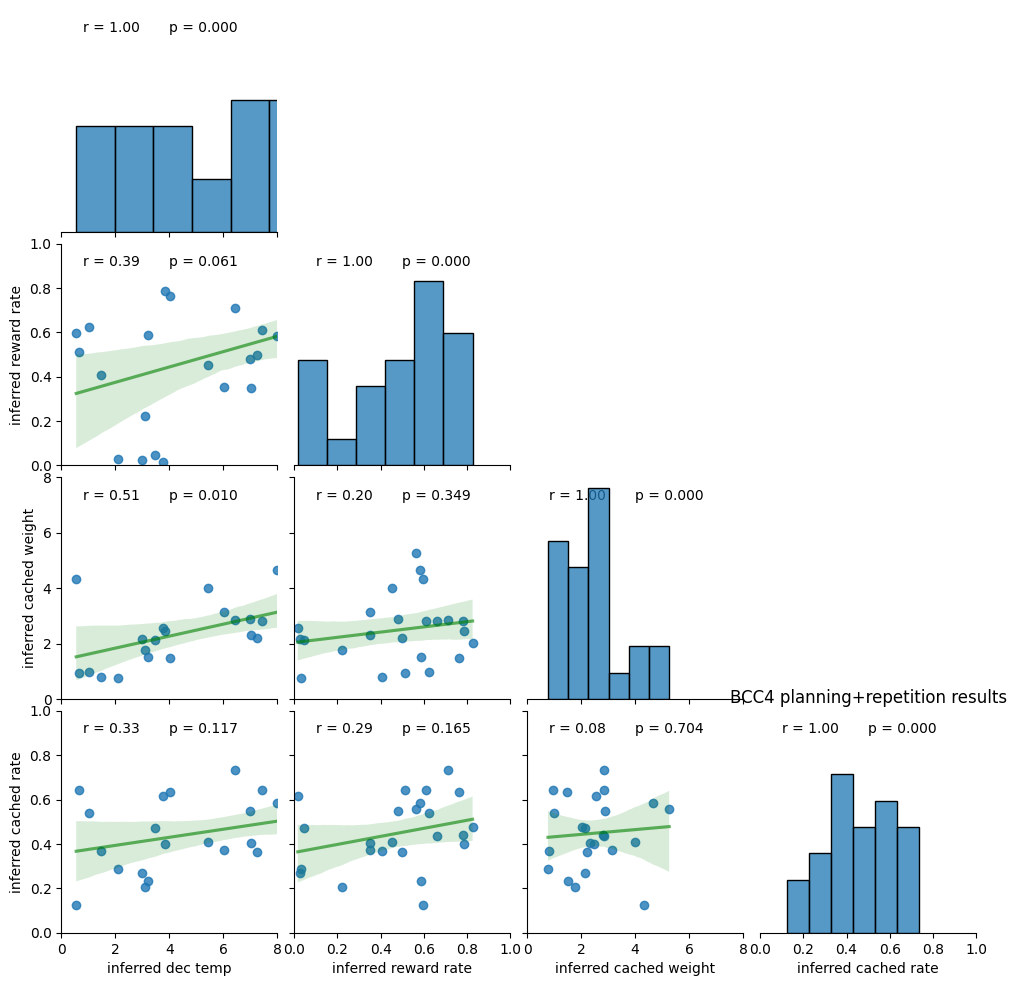

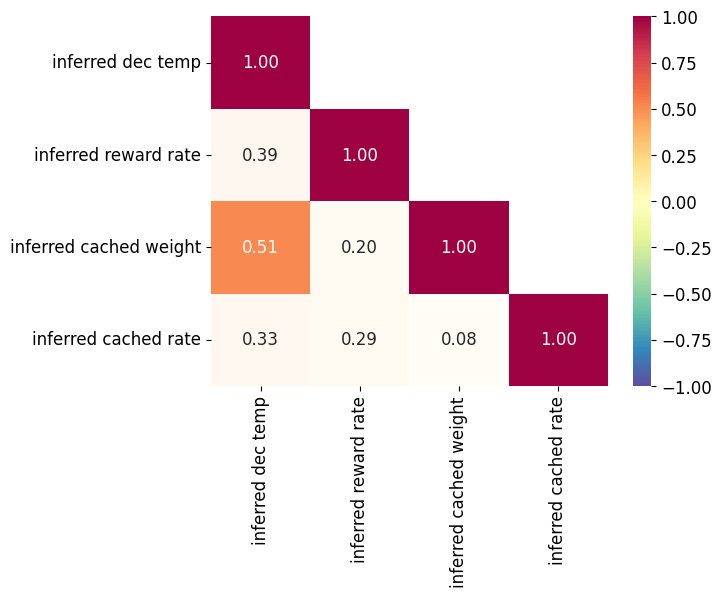

In [23]:
# BCC4 planning cached analysis

learn_rewards = True
learn_habit = False
use_h = False
learn_cached = True

param_names = []
param_ranges = []

prefix = "BCC"
model_name = "Bayesian prior-based contextual control model"
n_pars = 0
agnt_str = ""

if learn_rewards:
    n_pars += 2
    param_names += ["dec temp", "reward rate"]
    param_ranges += [[0,8], [0,1]]
    agnt_str += "_plan"

if learn_habit:
    # infer_h = True
    # infer_policy_rate = True 
    n_pars += 2
    agnt_str += "_habit"
    param_names += ["habitual tendency", "policy rate"]
    if use_h:
        agnt_str += "_h"
        param_ranges += [[0,1], [0,1]]
    else:
        agnt_str += "_weight"
        param_ranges += [[0,8], [0,1]]
# else:
#     infer_h = False
#     infer_policy_rate = False

if learn_cached:
    n_pars += 2
    param_names += ["cached weight", "cached rate"]
    param_ranges += [[0,8], [0,1]]
    agnt_str += "_cached"

assert n_pars > 0, "please turn any part of the agent on, it cannot run without any learning or inference."

# choose max decision temperature for numerical stability
max_dt = 6

BCC4_p_c_st_param_names = param_names.copy()
BCC4_p_c_st_param_ranges = param_ranges.copy()

# prepare for saving results
# make base filename and folder string
agent_type = prefix+"_"+str(n_pars)+"pars"+agnt_str+"sum_test_NO_context"
print(agent_type)

# prepare for saving results
# make base filename and folder string
fname_base = agent_type+"_inference_"
print(fname_base)
# define folder where we want to save data
base_dir = os.path.join(inference_folder,fname_base[:-1])

# make directory if it doesnt exist
if fname_base[:-1] not in os.listdir(inference_folder):
    os.mkdir(base_dir)

num_steps = 600

BCC4_p_c_st_mean_df, BCC4_p_c_st_sample_df, BCC4_p_c_st_locs_df = load_BCC_results(learn_rewards, learn_habit, learn_cached, base_dir, global_experiment_parameters, exp_mask, fname_base, num_steps, data, param_names, use_h=False)

BCC4_p_c_st_agent = tu.set_up_Bayesian_inference_agent(n_agents, learn_rewards, learn_habit, learn_cached, base_dir, global_experiment_parameters, data["valid"], remove_old=False, use_h=use_h)

BCC4_p_c_st_params = torch.stack([torch.tensor(BCC4_p_c_st_mean_df["inferred "+name]) for name in BCC4_p_c_st_param_names], dim=-1)

# param_plot_ranges = [[-0.25,1.25], [-0.25,1.25], [0,10]]

plt.figure()
vars_of_interest = ["inferred "+name for name in param_names]
f = sns.pairplot(data=BCC4_p_c_st_mean_df, kind='reg', diag_kind="hist", corner=True,
                    plot_kws={'line_kws': {'color': 'green', 'alpha': 0.6}},
                    x_vars=vars_of_interest, y_vars=vars_of_interest)
f.map(tu.annot_corrfunc)
for p, p_range in enumerate(param_ranges):
    f.axes[n_pars-1,p].set_xlim(p_range)
    f.axes[p,0].set_ylim(p_range)
plt.title("BCC4 planning+repetition results")
#plt.savefig(os.path.join(base_dir, fname_str+"_pairplot_means_inferred_corr.svg"))
plt.show()


plot_correlations(BCC4_p_c_st_mean_df, vars_of_interest, vars_of_interest)

In [24]:
# calculate agent log likelihood using mean params

BCC4_p_c_st_log_like = -calculate_log_likelihood(data, BCC4_p_c_st_agent, BCC4_p_c_st_locs_df, len(BCC4_p_c_st_param_names), global_experiment_parameters["trials"], global_experiment_parameters["T"])

BCC4_p_c_st_BIC = calculate_BIC(data, BCC4_p_c_st_agent, BCC4_p_c_st_locs_df, len(BCC4_p_c_st_param_names), global_experiment_parameters["trials"], global_experiment_parameters["T"])

BCC4_p_c_st_lppd = -calculate_lppd(data, BCC4_p_c_st_agent, BCC4_p_c_st_locs_df, len(BCC4_p_c_st_param_names), 
                            global_experiment_parameters["trials"], global_experiment_parameters["T"], max_samples=50)

BCC4_p_c_st_WAIC = -calculate_waic(data, BCC4_p_c_st_agent, BCC4_p_c_st_locs_df, len(BCC4_p_c_st_param_names), 
                            global_experiment_parameters["trials"], global_experiment_parameters["T"], max_samples=50)

measures_df = pd.concat([measures_df, pd.DataFrame({"subject": list(range(n_agents)), "measure": BCC4_p_c_st_log_like, "type": ["log likelihood"]*n_agents, "model": ["BCC4_p_c_st"]*n_agents})])
measures_df = pd.concat([measures_df, pd.DataFrame({"subject": list(range(n_agents)), "measure": BCC4_p_c_st_lppd, "type": ["lppd"]*n_agents, "model": ["BCC4_p_c_st"]*n_agents})])
measures_df = pd.concat([measures_df, pd.DataFrame({"subject": list(range(n_agents)), "measure": BCC4_p_c_st_BIC, "type": ["BIC"]*n_agents, "model": ["BCC4_p_c_st"]*n_agents})])
measures_df = pd.concat([measures_df, pd.DataFrame({"subject": list(range(n_agents)), "measure": BCC4_p_c_st_WAIC, "type": ["WAIC"]*n_agents, "model": ["BCC4_p_c_st"]*n_agents})])

print("BCC4_p_c_st log like", BCC4_p_c_st_log_like.mean())

print("BCC4_p_c_st BIC", BCC4_p_c_st_BIC.mean())

print("BCC4_p_c_st lppd", BCC4_p_c_st_lppd.mean())

gc.collect()

torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24

44443

### Load BCC6results, and plot correlations between inferred parameters

BCC_6pars_plan_habit_weight_cached_NO_context
BCC_6pars_plan_habit_weight_cached_NO_context_inference_
6
analyzing 24 data sets
6


/home/sarah/python_venvs/TwoStageStrategies/lib/python3.13/site-packages/pyro/params/param_store.py:334: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(inp

<Figure size 640x480 with 0 Axes>

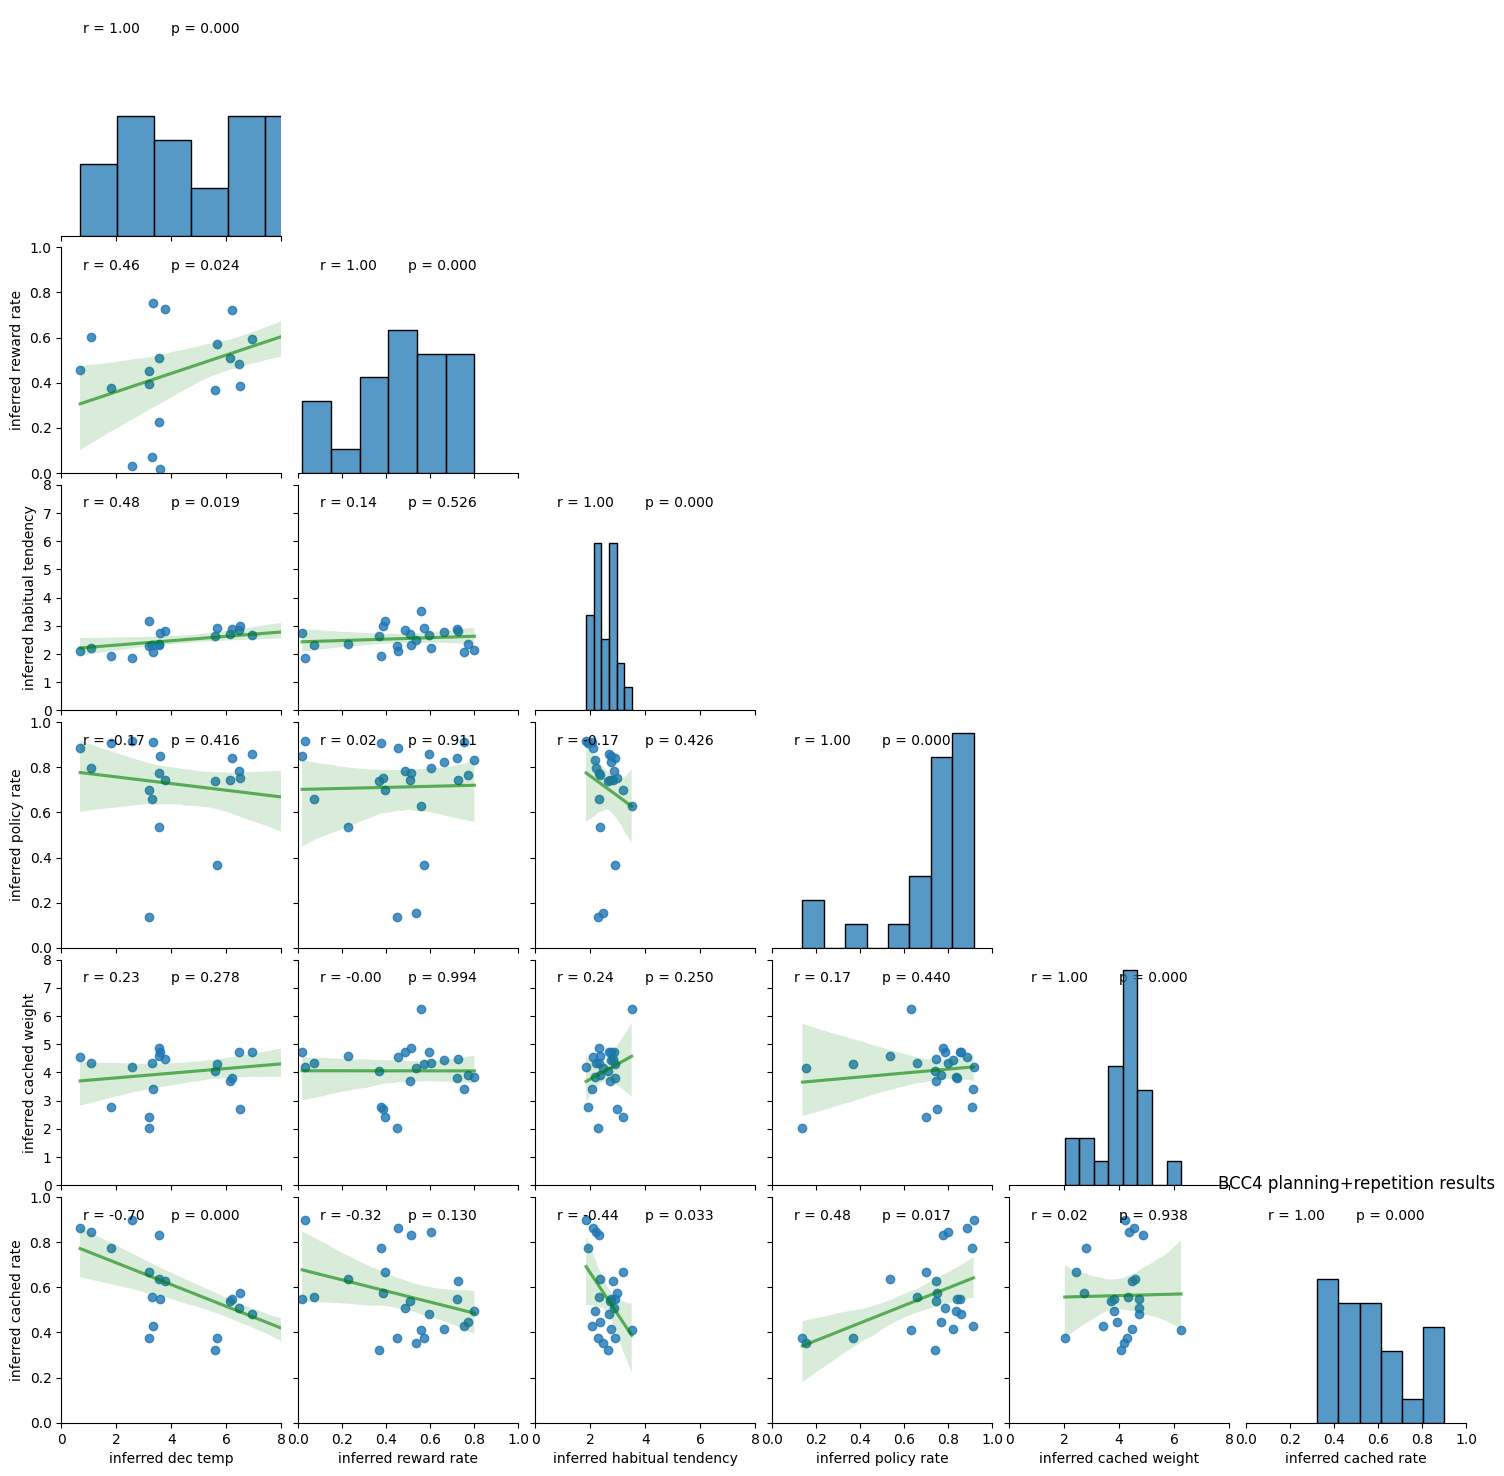

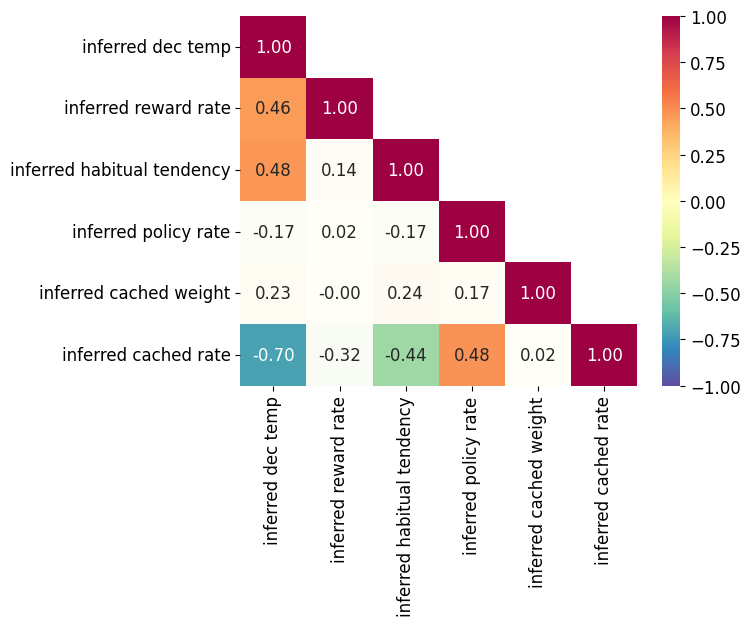

In [25]:
# BCC6 analysis

learn_rewards = True
learn_habit = True
use_h = False
learn_cached = True

param_names = []
param_ranges = []

prefix = "BCC"
model_name = "Bayesian prior-based contextual control model"
n_pars = 0
agnt_str = ""

if learn_rewards:
    n_pars += 2
    param_names += ["dec temp", "reward rate"]
    param_ranges += [[0,8], [0,1]]
    agnt_str += "_plan"

if learn_habit:
    # infer_h = True
    # infer_policy_rate = True 
    n_pars += 2
    agnt_str += "_habit"
    param_names += ["habitual tendency", "policy rate"]
    if use_h:
        agnt_str += "_h"
        param_ranges += [[0,1], [0,1]]
    else:
        agnt_str += "_weight"
        param_ranges += [[0,8], [0,1]]
# else:
#     infer_h = False
#     infer_policy_rate = False

if learn_cached:
    n_pars += 2
    param_names += ["cached weight", "cached rate"]
    param_ranges += [[0,8], [0,1]]
    agnt_str += "_cached"

assert n_pars > 0, "please turn any part of the agent on, it cannot run without any learning or inference."

# choose max decision temperature for numerical stability
max_dt = 6

BCC6_param_names = param_names.copy()
BCC6_param_ranges = param_ranges.copy()

# prepare for saving results
# make base filename and folder string
agent_type = prefix+"_"+str(n_pars)+"pars"+agnt_str+"_NO_context"
print(agent_type)

# prepare for saving results
# make base filename and folder string
fname_base = agent_type+"_inference_"
print(fname_base)
# define folder where we want to save data
base_dir = os.path.join(inference_folder,fname_base[:-1])

# make directory if it doesnt exist
if fname_base[:-1] not in os.listdir(inference_folder):
    os.mkdir(base_dir)

num_steps = 600

BCC6_mean_df, BCC6_sample_df, BCC6_locs_df = load_BCC_results(learn_rewards, learn_habit, learn_cached, base_dir, global_experiment_parameters, exp_mask, fname_base, num_steps, data, param_names, use_h=False)

BCC6_agent = tu.set_up_Bayesian_inference_agent(n_agents, learn_rewards, learn_habit, learn_cached, base_dir, global_experiment_parameters, data["valid"], remove_old=False, use_h=use_h)

BCC6_params = torch.stack([torch.tensor(BCC6_mean_df["inferred "+name]) for name in BCC6_param_names], dim=-1)

# param_plot_ranges = [[-0.25,1.25], [-0.25,1.25], [0,10]]

plt.figure()
vars_of_interest = ["inferred "+name for name in param_names]
f = sns.pairplot(data=BCC6_mean_df, kind='reg', diag_kind="hist", corner=True,
                    plot_kws={'line_kws': {'color': 'green', 'alpha': 0.6}},
                    x_vars=vars_of_interest, y_vars=vars_of_interest)
f.map(tu.annot_corrfunc)
for p, p_range in enumerate(param_ranges):
    f.axes[n_pars-1,p].set_xlim(p_range)
    f.axes[p,0].set_ylim(p_range)
plt.title("BCC4 planning+repetition results")
#plt.savefig(os.path.join(base_dir, fname_str+"_pairplot_means_inferred_corr.svg"))
plt.show()

plot_correlations(BCC6_mean_df, vars_of_interest, vars_of_interest)

In [26]:
# calculate agent log likelihood using mean params

BCC6_log_like = -calculate_log_likelihood(data, BCC6_agent, BCC6_locs_df, len(BCC6_param_names), global_experiment_parameters["trials"], global_experiment_parameters["T"])

BCC6_BIC = calculate_BIC(data, BCC6_agent, BCC6_locs_df, len(BCC6_param_names), global_experiment_parameters["trials"], global_experiment_parameters["T"])

BCC6_lppd = -calculate_lppd(data, BCC6_agent, BCC6_locs_df, len(BCC6_param_names), 
                            global_experiment_parameters["trials"], global_experiment_parameters["T"], max_samples=50)

BCC6_WAIC = -calculate_waic(data, BCC6_agent, BCC6_locs_df, len(BCC6_param_names), 
                            global_experiment_parameters["trials"], global_experiment_parameters["T"], max_samples=50)

measures_df = pd.concat([measures_df, pd.DataFrame({"subject": list(range(n_agents)), "measure": BCC6_log_like, "type": ["log likelihood"]*n_agents, "model": ["BCC6"]*n_agents})])
measures_df = pd.concat([measures_df, pd.DataFrame({"subject": list(range(n_agents)), "measure": BCC6_lppd, "type": ["lppd"]*n_agents, "model": ["BCC6"]*n_agents})])
measures_df = pd.concat([measures_df, pd.DataFrame({"subject": list(range(n_agents)), "measure": BCC6_BIC, "type": ["BIC"]*n_agents, "model": ["BCC6"]*n_agents})])
measures_df = pd.concat([measures_df, pd.DataFrame({"subject": list(range(n_agents)), "measure": BCC6_WAIC, "type": ["WAIC"]*n_agents, "model": ["BCC6"]*n_agents})])

print("BCC6 log like", BCC6_log_like.mean())

print("BCC6 BIC", BCC6_BIC.mean())

print("BCC6 lppd", BCC6_lppd.mean())

gc.collect()

torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24

2016

### Load BCC6 sum test results, and plot correlations between inferred parameters

BCC_6pars_plan_habit_weight_cachedsum_test_NO_context
BCC_6pars_plan_habit_weight_cachedsum_test_NO_context_inference_
6
analyzing 24 data sets
6


/home/sarah/python_venvs/TwoStageStrategies/lib/python3.13/site-packages/pyro/params/param_store.py:334: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(inp

<Figure size 640x480 with 0 Axes>

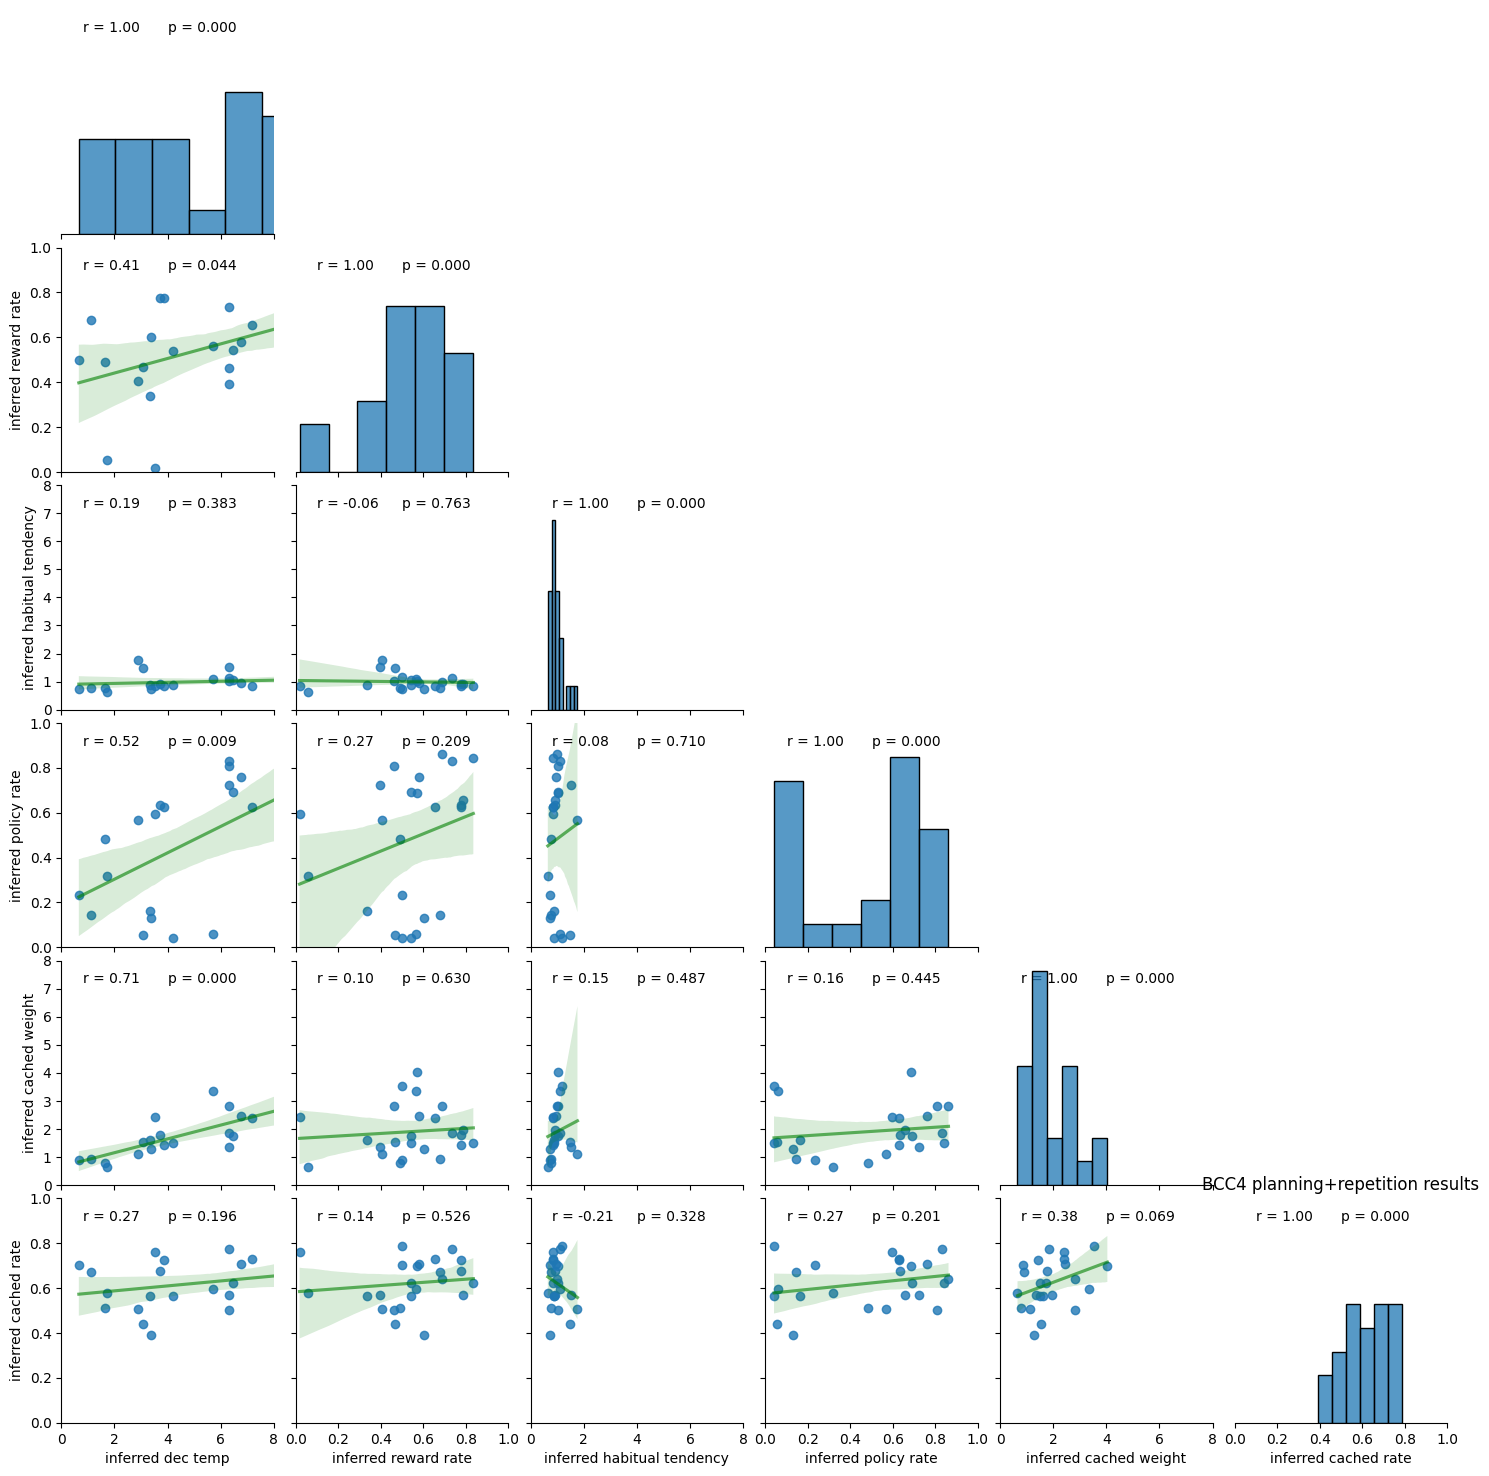

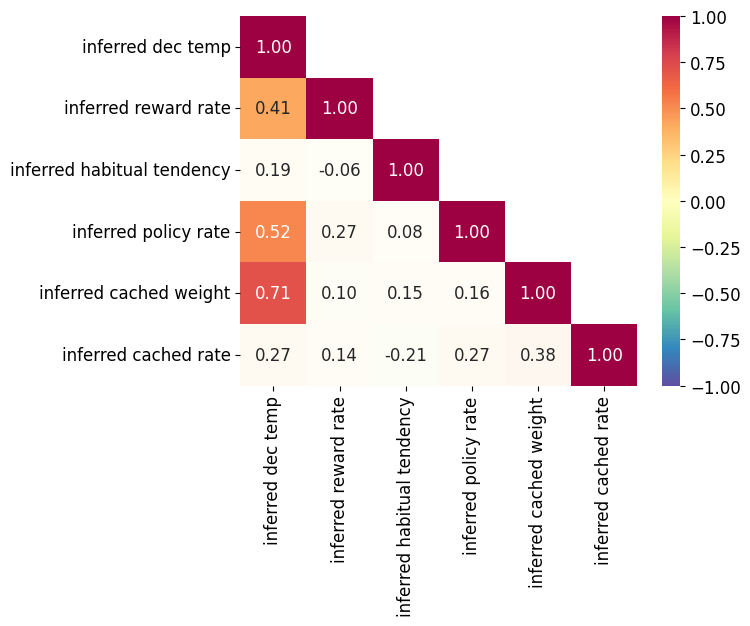

In [27]:
# BCC6 analysis

learn_rewards = True
learn_habit = True
use_h = False
learn_cached = True

param_names = []
param_ranges = []

prefix = "BCC"
model_name = "Bayesian prior-based contextual control model"
n_pars = 0
agnt_str = ""

if learn_rewards:
    n_pars += 2
    param_names += ["dec temp", "reward rate"]
    param_ranges += [[0,8], [0,1]]
    agnt_str += "_plan"

if learn_habit:
    # infer_h = True
    # infer_policy_rate = True 
    n_pars += 2
    agnt_str += "_habit"
    param_names += ["habitual tendency", "policy rate"]
    if use_h:
        agnt_str += "_h"
        param_ranges += [[0,1], [0,1]]
    else:
        agnt_str += "_weight"
        param_ranges += [[0,8], [0,1]]
# else:
#     infer_h = False
#     infer_policy_rate = False

if learn_cached:
    n_pars += 2
    param_names += ["cached weight", "cached rate"]
    param_ranges += [[0,8], [0,1]]
    agnt_str += "_cached"

assert n_pars > 0, "please turn any part of the agent on, it cannot run without any learning or inference."

# choose max decision temperature for numerical stability
max_dt = 6

BCC6_st_param_names = param_names.copy()
BCC6_st_param_ranges = param_ranges.copy()

# prepare for saving results
# make base filename and folder string
agent_type = prefix+"_"+str(n_pars)+"pars"+agnt_str+"sum_test_NO_context"
print(agent_type)

# prepare for saving results
# make base filename and folder string
fname_base = agent_type+"_inference_"
print(fname_base)
# define folder where we want to save data
base_dir = os.path.join(inference_folder,fname_base[:-1])

# make directory if it doesnt exist
if fname_base[:-1] not in os.listdir(inference_folder):
    os.mkdir(base_dir)

num_steps = 600

BCC6_st_mean_df, BCC6_st_sample_df, BCC6_st_locs_df = load_BCC_results(learn_rewards, learn_habit, learn_cached, base_dir, global_experiment_parameters, exp_mask, fname_base, num_steps, data, param_names, use_h=False)

BCC6_st_agent = tu.set_up_Bayesian_inference_agent(n_agents, learn_rewards, learn_habit, learn_cached, base_dir, global_experiment_parameters, data["valid"], remove_old=False, use_h=use_h)

BCC6_st_params = torch.stack([torch.tensor(BCC6_st_mean_df["inferred "+name]) for name in BCC6_st_param_names], dim=-1)

# param_plot_ranges = [[-0.25,1.25], [-0.25,1.25], [0,10]]

plt.figure()
vars_of_interest = ["inferred "+name for name in param_names]
f = sns.pairplot(data=BCC6_st_mean_df, kind='reg', diag_kind="hist", corner=True,
                    plot_kws={'line_kws': {'color': 'green', 'alpha': 0.6}},
                    x_vars=vars_of_interest, y_vars=vars_of_interest)
f.map(tu.annot_corrfunc)
for p, p_range in enumerate(param_ranges):
    f.axes[n_pars-1,p].set_xlim(p_range)
    f.axes[p,0].set_ylim(p_range)
plt.title("BCC4 planning+repetition results")
#plt.savefig(os.path.join(base_dir, fname_str+"_pairplot_means_inferred_corr.svg"))
plt.show()

plot_correlations(BCC6_st_mean_df, vars_of_interest, vars_of_interest)

In [28]:
# calculate agent log likelihood using mean params

BCC6_st_log_like = -calculate_log_likelihood(data, BCC6_st_agent, BCC6_st_locs_df, len(BCC6_st_param_names), global_experiment_parameters["trials"], global_experiment_parameters["T"])

BCC6_st_BIC = calculate_BIC(data, BCC6_st_agent, BCC6_st_locs_df, len(BCC6_st_param_names), global_experiment_parameters["trials"], global_experiment_parameters["T"])

BCC6_st_lppd = -calculate_lppd(data, BCC6_st_agent, BCC6_st_locs_df, len(BCC6_st_param_names), 
                            global_experiment_parameters["trials"], global_experiment_parameters["T"], max_samples=50)

BCC6_st_WAIC = -calculate_waic(data, BCC6_st_agent, BCC6_st_locs_df, len(BCC6_st_param_names), 
                            global_experiment_parameters["trials"], global_experiment_parameters["T"], max_samples=50)

measures_df = pd.concat([measures_df, pd.DataFrame({"subject": list(range(n_agents)), "measure": BCC6_st_log_like, "type": ["log likelihood"]*n_agents, "model": ["BCC6_st"]*n_agents})])
measures_df = pd.concat([measures_df, pd.DataFrame({"subject": list(range(n_agents)), "measure": BCC6_st_lppd, "type": ["lppd"]*n_agents, "model": ["BCC6_st"]*n_agents})])
measures_df = pd.concat([measures_df, pd.DataFrame({"subject": list(range(n_agents)), "measure": BCC6_st_BIC, "type": ["BIC"]*n_agents, "model": ["BCC6_st"]*n_agents})])
measures_df = pd.concat([measures_df, pd.DataFrame({"subject": list(range(n_agents)), "measure": BCC6_st_WAIC, "type": ["WAIC"]*n_agents, "model": ["BCC6_st"]*n_agents})])

print("BCC6_st log like", BCC6_st_log_like.mean())

print("BCC6_st BIC", BCC6_st_BIC.mean())

print("BCC6_st lppd", BCC6_st_lppd.mean())

gc.collect()

torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24])
torch.Size([24

2111

In [29]:
print(measures_df)

    subject     measure            type    model
0         0  333.412903  log likelihood     BCC2
1         1  376.051575  log likelihood     BCC2
2         2  334.442078  log likelihood     BCC2
3         3  333.300385  log likelihood     BCC2
4         4  346.700104  log likelihood     BCC2
..      ...         ...             ...      ...
19       19  637.377258            WAIC  BCC6_st
20       20  597.320557            WAIC  BCC6_st
21       21  697.997925            WAIC  BCC6_st
22       22  698.933777            WAIC  BCC6_st
23       23  602.771545            WAIC  BCC6_st

[576 rows x 4 columns]


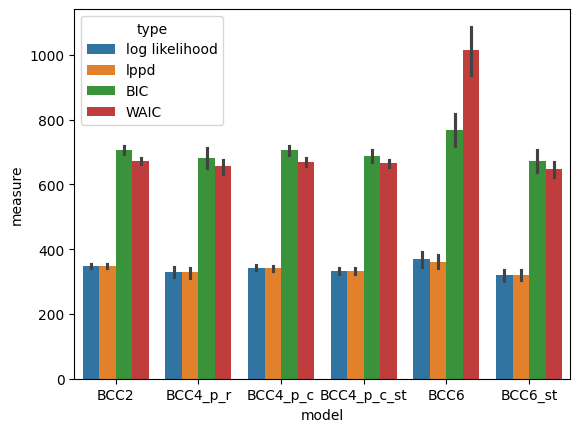

In [30]:
# plot differences in fit for BCC model

plt.figure()
sns.barplot(data=measures_df, x="model", y="measure", hue="type")
plt.show()

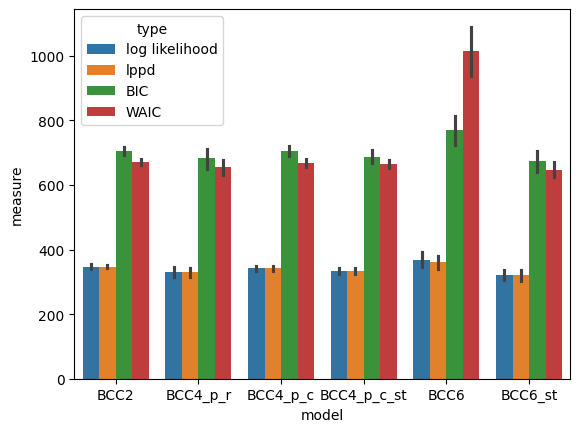

In [31]:
plt.figure()
sns.barplot(data=measures_df, x="model", y="measure", hue="type")
plt.savefig(os.path.join(model_comp_folder, "model_comparison.svg"))
plt.savefig(os.path.join(model_comp_folder, "model_comparison.png"))
plt.show()

In [32]:
with open(non_fit_file, "r") as f:
    all_didnt_fit = json.load(f)

did_fit = torch.ones(n_agents).bool()
did_fit[all_didnt_fit] = False

print(did_fit.sum())

n_fit = did_fit.sum()

tensor(21)


In [33]:
all_total_log_likes = torch.stack([BCC2_log_like, BCC4_p_r_log_like, BCC4_p_c_log_like, BCC4_p_c_st_log_like, BCC6_log_like, BCC6_st_log_like], dim=-1)

winning_model = all_total_log_likes.argmin(dim=-1)

print("BCC2 wins", (winning_model==0).sum())
print("BCC4_p_r wins", (winning_model==1).sum())
print("BCC4_p_c wins", (winning_model==2).sum())
print("BCC4_p_c_st wins", (winning_model==3).sum())
print("BCC6 wins", (winning_model==4).sum())
print("BCC6_st wins", (winning_model==5).sum())

all_log_likes_exc_prob, all_log_likes_avg_best_model = calculate_exceedance_prob(-all_total_log_likes)

BCC2 wins tensor(3)
BCC4_p_r wins tensor(0)
BCC4_p_c wins tensor(1)
BCC4_p_c_st wins tensor(1)
BCC6 wins tensor(0)
BCC6_st wins tensor(19)
p model mean according to measure tensor([9.0217e-02, 2.4135e-02, 5.4922e-02, 1.4530e-01, 1.3703e-04, 6.8529e-01])
best model: tensor(5) exceedance prob tensor(0.9980)
is significantly different from uniform? TtestResult(statistic=np.float64(121.91155214591787), pvalue=np.float64(0.0), df=np.int64(499))


In [34]:
all_total_log_likes_did_fit = torch.stack([BCC2_log_like, BCC4_p_r_log_like, BCC4_p_c_log_like, BCC4_p_c_st_log_like, BCC6_log_like, BCC6_st_log_like], dim=-1)[did_fit]

winning_model = all_total_log_likes_did_fit.argmin(dim=-1)

print("BCC2 wins", (winning_model==0).sum())
print("BCC4_p_r wins", (winning_model==1).sum())
print("BCC4_p_c wins", (winning_model==2).sum())
print("BCC4_p_c_st wins", (winning_model==3).sum())
print("BCC6 wins", (winning_model==4).sum())
print("BCC6_st wins", (winning_model==5).sum())

all_log_likes_exc_prob_did_fit, all_log_likes_avg_best_model_did_fit = calculate_exceedance_prob(-all_total_log_likes_did_fit)

BCC2 wins tensor(1)
BCC4_p_r wins tensor(0)
BCC4_p_c wins tensor(1)
BCC4_p_c_st wins tensor(1)
BCC6 wins tensor(0)
BCC6_st wins tensor(18)
p model mean according to measure tensor([4.4725e-02, 1.5099e-02, 2.8754e-02, 1.4161e-01, 1.5661e-04, 7.6966e-01])
best model: tensor(5) exceedance prob tensor(1.)
is significantly different from uniform? TtestResult(statistic=np.float64(147.07651431343177), pvalue=np.float64(0.0), df=np.int64(499))


In [35]:
BCC4_p_r_BCC4_p_c_st_total_log_likes = torch.stack([BCC4_p_r_log_like, BCC4_p_c_st_log_like], dim=-1)

winning_model = BCC4_p_r_BCC4_p_c_st_total_log_likes.argmin(dim=-1)

print("BCC4_p_r wins", (winning_model==0).sum())
print("BCC4_p_c_st wins", (winning_model==1).sum())

BCC4_p_r_BCC4_p_c_log_likes_exc_prob, BCC4_p_r_BCC4_p_c_total_log_likes_avg_best_model = calculate_exceedance_prob(-BCC4_p_r_BCC4_p_c_st_total_log_likes)

BCC4_p_r wins tensor(8)
BCC4_p_c_st wins tensor(16)
p model mean according to measure tensor([0.3215, 0.6785])
best model: tensor(1) exceedance prob tensor(0.9580)
is significantly different from uniform? TtestResult(statistic=np.float64(40.76875076003491), pvalue=np.float64(3.044728188375195e-161), df=np.int64(499))


In [36]:
BCC4_p_r_BCC4_p_c_st_total_log_likes_did_fit = torch.stack([BCC4_p_r_log_like, BCC4_p_c_st_log_like], dim=-1)[did_fit]

winning_model = BCC4_p_r_BCC4_p_c_st_total_log_likes_did_fit.argmin(dim=-1)

print("BCC4_p_r wins", (winning_model==0).sum())
print("BCC4_p_c_st wins", (winning_model==1).sum())

BCC4_p_r_BCC4_p_c_log_likes_exc_prob_did_fit, BCC4_p_r_BCC4_p_c_total_log_likes_avg_best_model_did_fit = calculate_exceedance_prob(-BCC4_p_r_BCC4_p_c_st_total_log_likes_did_fit)

BCC4_p_r wins tensor(7)
BCC4_p_c_st wins tensor(14)
p model mean according to measure tensor([0.3362, 0.6638])
best model: tensor(1) exceedance prob tensor(0.9360)
is significantly different from uniform? TtestResult(statistic=np.float64(34.93103775189878), pvalue=np.float64(1.9467515003008697e-136), df=np.int64(499))


In [37]:
all_total_WAICs = torch.stack([BCC2_WAIC, BCC4_p_r_WAIC, BCC4_p_c_WAIC, BCC4_p_c_st_WAIC, BCC6_WAIC, BCC6_st_WAIC], dim=-1)

winning_model = all_total_WAICs.argmin(dim=-1)

print("BCC2 wins", (winning_model==0).sum())
print("BCC4_p_r wins", (winning_model==1).sum())
print("BCC4_p_c wins", (winning_model==2).sum())
print("BCC4_p_c_st wins", (winning_model==3).sum())
print("BCC6 wins", (winning_model==4).sum())
print("BCC6_st wins", (winning_model==5).sum())

p_model = torch.nn.functional.softmax(-2*all_total_WAICs, dim=-1)
print(p_model.shape)

print(p_model.mean(dim=0))

p_model_total = torch.nn.functional.softmax(-2*all_total_WAICs.sum(dim=0), dim=-1)

print(p_model_total)

all_WAICs_exc_prob, all_WAICs_avg_best_model = calculate_exceedance_prob(-2*all_total_WAICs)

BCC2 wins tensor(5)
BCC4_p_r wins tensor(0)
BCC4_p_c wins tensor(3)
BCC4_p_c_st wins tensor(3)
BCC6 wins tensor(0)
BCC6_st wins tensor(13)
torch.Size([24, 6])
tensor([0.2174, 0.0087, 0.1225, 0.1443, 0.0000, 0.5070])
tensor([0., 0., 0., 0., 0., 1.])
p model mean according to measure tensor([0.2174, 0.0087, 0.1225, 0.1443, 0.0000, 0.5070])


ValueError: Expected parameter concentration (Tensor of shape (6,)) of distribution Dirichlet(concentration: torch.Size([6])) to satisfy the constraint IndependentConstraint(GreaterThan(lower_bound=0.0), 1), but found invalid values:
tensor([ 5.2186,  0.2098,  2.9397,  3.4642,  0.0000, 12.1677])

In [ ]:
all_total_WAICs_did_fit = torch.stack([BCC2_WAIC, BCC4_p_r_WAIC, BCC4_p_c_WAIC, BCC4_p_c_st_WAIC, BCC6_WAIC, BCC6_st_WAIC], dim=-1)[did_fit]

winning_model = all_total_WAICs_did_fit.argmin(dim=-1)

print("BCC2 wins", (winning_model==0).sum())
print("BCC4_p_r wins", (winning_model==1).sum())
print("BCC4_p_c wins", (winning_model==2).sum())
print("BCC4_p_c_st wins", (winning_model==3).sum())
print("BCC6 wins", (winning_model==4).sum())
print("BCC6_st wins", (winning_model==5).sum())

p_model = torch.nn.functional.softmax(-2*all_total_WAICs_did_fit, dim=-1)
print(p_model.shape)

print(p_model.mean(dim=0))

p_model_total = torch.nn.functional.softmax(-2*all_total_WAICs_did_fit.sum(dim=0), dim=-1)

print(p_model_total)

all_WAICs_exc_prob_did_fit, all_WAICs_avg_best_model_did_fit = calculate_exceedance_prob(-2*all_total_WAICs_did_fit)

BCC2 wins tensor(2)
BCC4_p_r wins tensor(0)
BCC4_p_c wins tensor(3)
BCC4_p_c_st wins tensor(3)
BCC6 wins tensor(0)
BCC6_st wins tensor(13)
torch.Size([21, 6])
tensor([0.1057, 0.0100, 0.1400, 0.1650, 0.0000, 0.5794])
tensor([0., 0., 0., 0., 0., 1.])
p model mean according to measure tensor([0.1057, 0.0100, 0.1400, 0.1650, 0.0000, 0.5794])


ValueError: Expected parameter concentration (Tensor of shape (6,)) of distribution Dirichlet(concentration: torch.Size([6])) to satisfy the constraint IndependentConstraint(GreaterThan(lower_bound=0.0), 1), but found invalid values:
tensor([ 2.2187,  0.2098,  2.9397,  3.4642,  0.0000, 12.1676])

In [ ]:
BCC4_p_r_BCC4_p_c_st_total_WAICs = torch.stack([BCC4_p_r_WAIC, BCC4_p_c_st_WAIC], dim=-1)

winning_model = BCC4_p_r_BCC4_p_c_st_total_WAICs.argmin(dim=-1)

print("BCC4_p_r wins", (winning_model==0).sum())
print("BCC4_p_c_st wins", (winning_model==1).sum())

BCC4_p_r_BCC4_p_c_st_WAICs_exc_prob, BCC4_p_r_BCC4_p_c_st_WAICs_avg_best_model = calculate_exceedance_prob(-2*BCC4_p_r_BCC4_p_c_st_total_WAICs)

BCC4_p_r wins tensor(12)
BCC4_p_c_st wins tensor(12)
p model mean according to measure tensor([0.5114, 0.4886])
best model: tensor(0) exceedance prob tensor(0.5620)
is significantly different from uniform? TtestResult(statistic=np.float64(3.6216248485908613), pvalue=np.float64(0.000161349972196374), df=np.int64(499))


In [ ]:
BCC4_p_r_BCC4_p_c_st_total_WAICs_did_fit = torch.stack([BCC4_p_r_WAIC, BCC4_p_c_st_WAIC], dim=-1)[did_fit]

winning_model = BCC4_p_r_BCC4_p_c_st_total_WAICs_did_fit.argmin(dim=-1)

print("BCC4_p_r wins", (winning_model==0).sum())
print("BCC4_p_c_st wins", (winning_model==1).sum())

BCC4_p_r_BCC4_p_c_st_WAICs_exc_prob_did_fit, BCC4_p_r_BCC4_p_c_st_WAICs_avg_best_model_did_fit = calculate_exceedance_prob(-2*BCC4_p_r_BCC4_p_c_st_total_WAICs_did_fit)

BCC4_p_r wins tensor(12)
BCC4_p_c_st wins tensor(9)
p model mean according to measure tensor([0.5845, 0.4155])
best model: tensor(0) exceedance prob tensor(0.7860)
is significantly different from uniform? TtestResult(statistic=np.float64(17.925322863187688), pvalue=np.float64(3.9034875305308847e-56), df=np.int64(499))


3
  winning model  # of participants
0          BCC2                  3
1      BCC4_p_r                  0
2      BCC4_p_c                  1
3   BCC4_p_c_st                  1
4          BCC6                  0
5       BCC6_st                 19


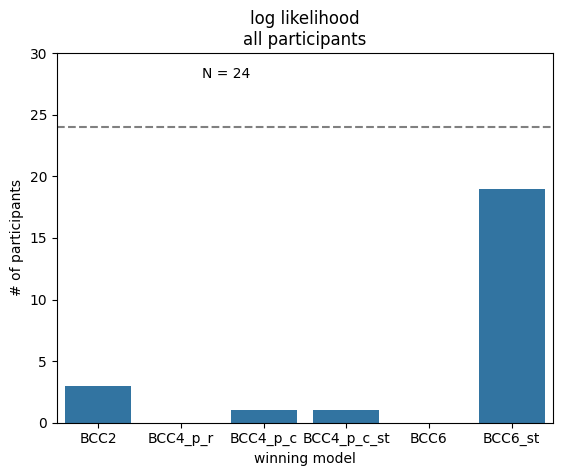

In [ ]:
# plot model comparisons

plt.figure()
winning_model = all_total_log_likes.argmin(dim=-1)
print((winning_model==0).sum().numpy())
plot_df = pd.DataFrame({"winning model": ["BCC2", "BCC4_p_r", "BCC4_p_c", "BCC4_p_c_st", "BCC6", "BCC6_st"], 
                        "# of participants": torch.stack([(winning_model==i).sum() for i in range(6)])})
print(plot_df)
sns.barplot(data=plot_df, y="# of participants", x="winning model")
plt.axhline(y=n_agents, color='grey', linestyle='--')
plt.text(1.25, 28, f"N = {n_agents}")
plt.text(0.6, 25, f"exceedence probabality {all_log_likes_exc_prob:.2f}")
plt.ylim([0,30])
plt.title("log likelihood\nall participants")
plt.savefig(os.path.join(model_comp_folder, "exc_prob_llike_all.svg"))
plt.show()

0
  winning model  # of participants
0          BCC2                  0
1      BCC4_p_r                  0
2      BCC4_p_c                  0
3   BCC4_p_c_st                  1
4          BCC6                  0
5       BCC6_st                 20


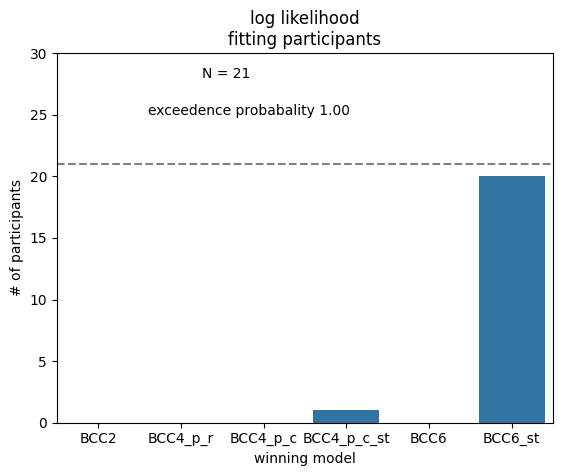

In [ ]:
# plot model comparisons

plt.figure()
winning_model = all_total_log_likes_did_fit.argmin(dim=-1)
print((winning_model==0).sum().numpy())
plot_df = pd.DataFrame({"winning model": ["BCC2", "BCC4_p_r", "BCC4_p_c", "BCC4_p_c_st", "BCC6", "BCC6_st"], 
                        "# of participants": torch.stack([(winning_model==i).sum() for i in range(6)])})
print(plot_df)
sns.barplot(data=plot_df, y="# of participants", x="winning model")
plt.axhline(y=n_fit, color='grey', linestyle='--')
plt.text(1.25, 28, f"N = {n_fit}")
plt.text(0.6, 25, f"exceedence probabality {all_log_likes_exc_prob_did_fit:.2f}")
plt.ylim([0,30])
plt.title("log likelihood\nfitting participants")
plt.savefig(os.path.join(model_comp_folder, "exc_prob_llike_all.svg"))
plt.show()

13
  winning model  # of participants
0      BCC4_p_r                 13
1   BCC4_p_c_st                 11


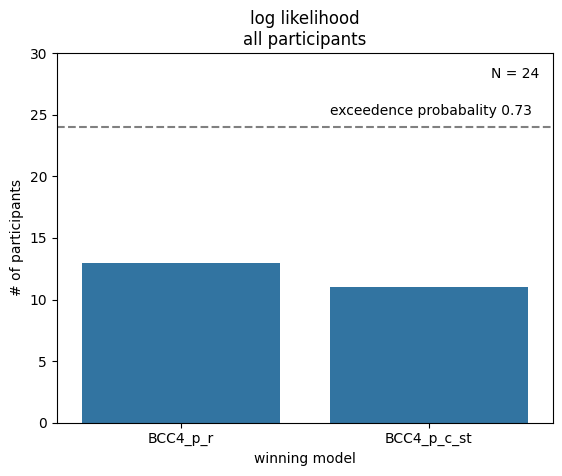

In [ ]:
# plot model comparisons

plt.figure()
winning_model = BCC4_p_r_BCC4_p_c_st_total_log_likes.argmin(dim=-1)
print((winning_model==0).sum().numpy())
plot_df = pd.DataFrame({"winning model": ["BCC4_p_r", "BCC4_p_c_st"], 
                        "# of participants": torch.stack([(winning_model==i).sum() for i in range(2)])})
print(plot_df)
sns.barplot(data=plot_df, y="# of participants", x="winning model")
plt.axhline(y=n_agents, color='grey', linestyle='--')
plt.text(1.25, 28, f"N = {n_agents}")
plt.text(0.6, 25, f"exceedence probabality {BCC4_p_r_BCC4_p_c_log_likes_exc_prob:.2f}")
plt.ylim([0,30])
plt.title("log likelihood\nall participants")
plt.savefig(os.path.join(model_comp_folder, "exc_prob_llike_all.svg"))
plt.show()

12
  winning model  # of participants
0      BCC4_p_r                 12
1   BCC4_p_c_st                  9


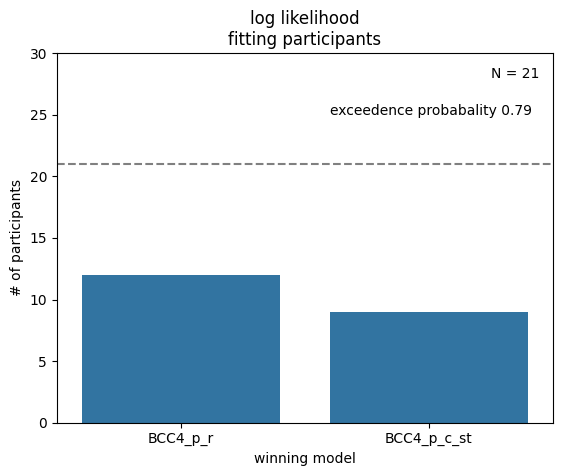

In [ ]:
# plot model comparisons

plt.figure()
winning_model = BCC4_p_r_BCC4_p_c_st_total_log_likes_did_fit.argmin(dim=-1)
print((winning_model==0).sum().numpy())
plot_df = pd.DataFrame({"winning model": ["BCC4_p_r", "BCC4_p_c_st"], 
                        "# of participants": torch.stack([(winning_model==i).sum() for i in range(2)])})
print(plot_df)
sns.barplot(data=plot_df, y="# of participants", x="winning model")
plt.axhline(y=n_fit, color='grey', linestyle='--')
plt.text(1.25, 28, f"N = {n_fit}")
plt.text(0.6, 25, f"exceedence probabality {BCC4_p_r_BCC4_p_c_log_likes_exc_prob_did_fit:.2f}")
plt.ylim([0,30])
plt.title("log likelihood\nfitting participants")
plt.savefig(os.path.join(model_comp_folder, "exc_prob_llike_all.svg"))
plt.show()

4
  winning model  # of participants
0          BCC2                  4
1      BCC4_p_r                  1
2      BCC4_p_c                  3
3   BCC4_p_c_st                  0
4          BCC6                  0
5       BCC6_st                 16


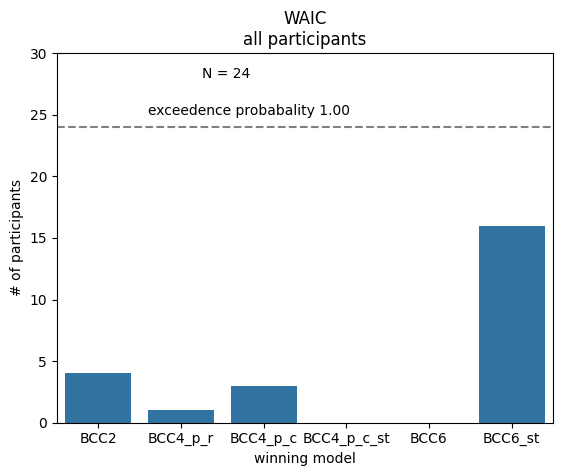

In [ ]:
# plot model comparisons

plt.figure()
winning_model = all_total_WAICs.argmin(dim=-1)
print((winning_model==0).sum().numpy())
plot_df = pd.DataFrame({"winning model": ["BCC2", "BCC4_p_r", "BCC4_p_c", "BCC4_p_c_st", "BCC6", "BCC6_st"], 
                        "# of participants": torch.stack([(winning_model==i).sum() for i in range(6)])})
print(plot_df)
sns.barplot(data=plot_df, y="# of participants", x="winning model")
plt.axhline(y=n_agents, color='grey', linestyle='--')
plt.text(1.25, 28, f"N = {n_agents}")
plt.text(0.6, 25, f"exceedence probabality {all_WAICs_exc_prob:.2f}")
plt.ylim([0,30])
plt.title("WAIC\nall participants")
plt.savefig(os.path.join(model_comp_folder, "exc_prob_llike_all.svg"))
plt.show()

In [ ]:
# plot model comparisons

plt.figure()
winning_model = all_total_WAICs_did_fit.argmin(dim=-1)
print((winning_model==0).sum().numpy())
plot_df = pd.DataFrame({"winning model": ["BCC2", "BCC4_p_r", "BCC4_p_c", "BCC4_p_c_st", "BCC6", "BCC6_st"], 
                        "# of participants": torch.stack([(winning_model==i).sum() for i in range(6)])})
print(plot_df)
sns.barplot(data=plot_df, y="# of participants", x="winning model")
plt.axhline(y=n_fit, color='grey', linestyle='--')
plt.text(1.25, 28, f"N = {n_fit}")
plt.text(0.6, 25, f"exceedence probabality {all_WAICs_exc_prob_did_fit:.2f}")
plt.ylim([0,30])
plt.title("WAIC\nfitting participants")
plt.savefig(os.path.join(model_comp_folder, "exc_prob_llike_all.svg"))
plt.show()

NameError: name 'all_total_WAICs_did_fit' is not defined

<Figure size 640x480 with 0 Axes>

p model mean according to measure tensor([0.2591, 0.0087, 0.1836, 0.5485])
best model: tensor(3) exceedance prob tensor(0.9440)
is significantly different from uniform? TtestResult(statistic=np.float64(68.29096817217388), pvalue=np.float64(1.2241695723086368e-255), df=np.int64(499))
6
           winning model  # of participants
0        plan\n(2 param)                  6
1    plan+rep\n(4 param)                  0
2  plan+cache\n(4 param)                  4
3    combined\n(6 param)                 14


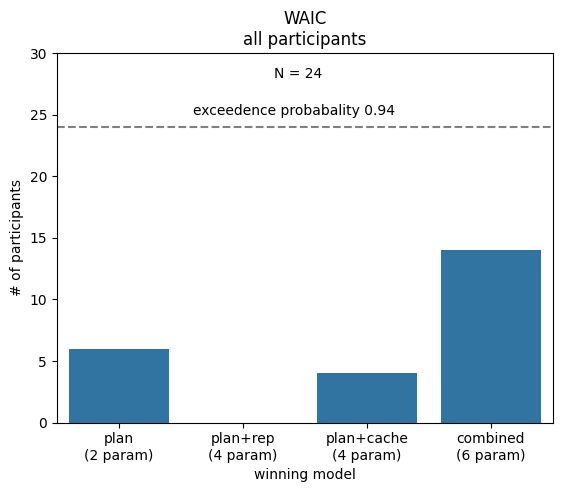

In [ ]:
# plot model comparisons

plt.figure()
winning_model = all_total_WAICs[...,(0,1,3,5)].argmin(dim=-1)

sub_WAICs_exc_prob, sub_WAICs_avg_best_model = calculate_exceedance_prob(-2*all_total_WAICs[...,(0,1,3,5)])

print((winning_model==0).sum().numpy())
plot_df = pd.DataFrame({"winning model": ["plan\n(2 param)", "plan+rep\n(4 param)", "plan+cache\n(4 param)", "combined\n(6 param)"], 
                        "# of participants": torch.stack([(winning_model==i).sum() for i in range(4)])})
print(plot_df)
sns.barplot(data=plot_df, y="# of participants", x="winning model")
plt.axhline(y=n_agents, color='grey', linestyle='--')
plt.text(1.25, 28, f"N = {n_agents}")
plt.text(0.6, 25, f"exceedence probabality {sub_WAICs_exc_prob:.2f}")
plt.ylim([0,30])
plt.title("WAIC\nall participants")
plt.savefig(os.path.join(model_comp_folder, "exc_prob_llike_all.svg"))
plt.show()

In [ ]:
# plot model comparisons

plt.figure()
winning_model = all_total_WAICs_did_fit[...,(0,1,3,5)].argmin(dim=-1)

sub_WAICs_exc_prob_did_fit, sub_WAICs_avg_best_model_did_fit = calculate_exceedance_prob(-2*all_total_WAICs_did_fit[...,(0,1,3,5)])

print((winning_model==0).sum().numpy())
plot_df = pd.DataFrame({"winning model": ["plan\n(2 param)", "plan+rep\n(4 param)", "plan+cache\n(4 param)", "combined\n(6 param)"], 
                        "# of participants": torch.stack([(winning_model==i).sum() for i in range(4)])})
print(plot_df)
sns.barplot(data=plot_df, y="# of participants", x="winning model")
plt.axhline(y=n_fit, color='grey', linestyle='--')
plt.text(1.25, 28, f"N = {n_fit}")
plt.text(0.6, 25, f"exceedence probabality {sub_WAICs_exc_prob_did_fit:.2f}")
plt.ylim([0,30])
plt.title("WAIC\nfitting participants")
plt.savefig(os.path.join(model_comp_folder, "exc_prob_llike_all.svg"))
plt.show()

NameError: name 'all_total_WAICs_did_fit' is not defined

<Figure size 640x480 with 0 Axes>

12
  winning model  # of participants
0      BCC4_p_r                 12
1   BCC4_p_c_st                 12


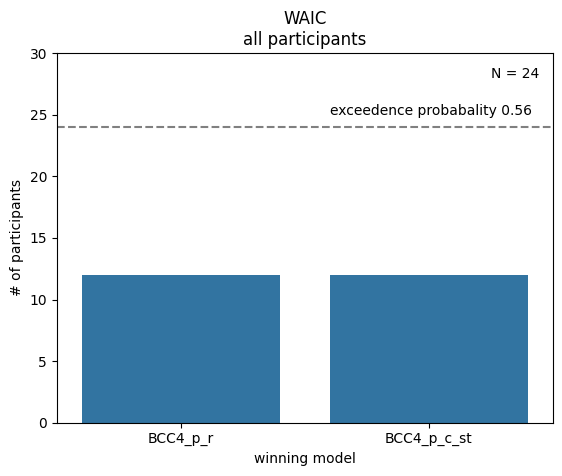

In [ ]:
# plot model comparisons

plt.figure()
winning_model = BCC4_p_r_BCC4_p_c_st_total_WAICs.argmin(dim=-1)
print((winning_model==0).sum().numpy())
plot_df = pd.DataFrame({"winning model": ["BCC4_p_r", "BCC4_p_c_st"], 
                        "# of participants": torch.stack([(winning_model==i).sum() for i in range(2)])})
print(plot_df)
sns.barplot(data=plot_df, y="# of participants", x="winning model")
plt.axhline(y=n_agents, color='grey', linestyle='--')
plt.text(1.25, 28, f"N = {n_agents}")
plt.text(0.6, 25, f"exceedence probabality {BCC4_p_r_BCC4_p_c_st_WAICs_exc_prob:.2f}")
plt.ylim([0,30])
plt.title("WAIC\nall participants")
plt.savefig(os.path.join(model_comp_folder, "exc_prob_llike_all.svg"))
plt.show()

12
  winning model  # of participants
0      BCC4_p_r                 12
1      BCC4_p_c                  9


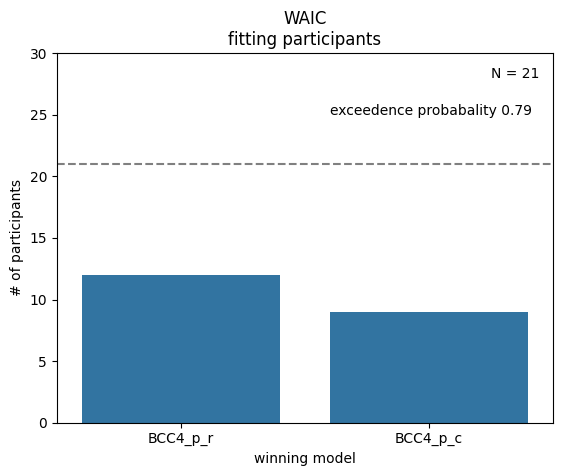

In [ ]:
# plot model comparisons

plt.figure()
winning_model = BCC4_p_r_BCC4_p_c_st_total_WAICs_did_fit.argmin(dim=-1)
print((winning_model==0).sum().numpy())
plot_df = pd.DataFrame({"winning model": ["BCC4_p_r", "BCC4_p_c"], 
                        "# of participants": torch.stack([(winning_model==i).sum() for i in range(2)])})
print(plot_df)
sns.barplot(data=plot_df, y="# of participants", x="winning model")
plt.axhline(y=n_fit, color='grey', linestyle='--')
plt.text(1.25, 28, f"N = {n_fit}")
plt.text(0.6, 25, f"exceedence probabality {BCC4_p_r_BCC4_p_c_st_WAICs_exc_prob_did_fit:.2f}")
plt.ylim([0,30])
plt.title("WAIC\nfitting participants")
plt.savefig(os.path.join(model_comp_folder, "exc_prob_llike_all.svg"))
plt.show()

In [ ]:
group_surely_BCC4 = torch.bitwise_and(BCC4_MFMB4_total_log_likes.argmin(dim=-1) == 0, BCC4_MFMB4_total_WAICs.argmin(dim=-1) == 0)
group_surely_MFMB4 = torch.bitwise_and(BCC4_MFMB4_total_log_likes.argmin(dim=-1) == 1, BCC4_MFMB4_total_WAICs.argmin(dim=-1) == 1)
group_log_MFMB4_WAIC_BCC4 = torch.bitwise_and(BCC4_MFMB4_total_log_likes.argmin(dim=-1) == 1, BCC4_MFMB4_total_WAICs.argmin(dim=-1) == 0)
group_log_BCC4_WAIC_MFMB4 = torch.bitwise_and(BCC4_MFMB4_total_log_likes.argmin(dim=-1) == 0, BCC4_MFMB4_total_WAICs.argmin(dim=-1) == 1)

print("all", BCC4_MFMB4_total_log_likes.shape[0], BCC4_MFMB4_total_WAICs.shape[0])
print("surely BCC4", group_surely_BCC4.sum())
print("surely MFMB4", group_surely_MFMB4.sum())
print("log MFMB4 waic BCC4", group_log_MFMB4_WAIC_BCC4.sum())
print("log BCC4 waic MFMB4", group_log_BCC4_WAIC_MFMB4.sum())

print("all", group_surely_BCC4.sum()+group_surely_MFMB4.sum()+group_log_MFMB4_WAIC_BCC4.sum()+group_log_BCC4_WAIC_MFMB4.sum())

all 188 188
surely BCC4 tensor(69)
surely MFMB4 tensor(63)
log MFMB4 waic BCC4 tensor(41)
log BCC4 waic MFMB4 tensor(15)
all tensor(188)


In [ ]:
winning_model = []

for n in range(n_agents):
    if group_surely_BCC4[n]:
        winning_model.append("BCC4")
    elif group_surely_MFMB4[n]:
        winning_model.append("MFMB4")
    elif group_log_MFMB4_WAIC_BCC4[n]:
        winning_model.append("log MFMB4 WAIC BCC4")
    elif group_log_BCC4_WAIC_MFMB4[n]:
        winning_model.append("log BCC4 WAIC MFMB4")
print(winning_model)

['BCC4', 'MFMB4', 'BCC4', 'log MFMB4 WAIC BCC4', 'log MFMB4 WAIC BCC4', 'MFMB4', 'log MFMB4 WAIC BCC4', 'MFMB4', 'MFMB4', 'MFMB4', 'log MFMB4 WAIC BCC4', 'MFMB4', 'BCC4', 'MFMB4', 'log MFMB4 WAIC BCC4', 'log MFMB4 WAIC BCC4', 'log MFMB4 WAIC BCC4', 'log BCC4 WAIC MFMB4', 'MFMB4', 'log MFMB4 WAIC BCC4', 'BCC4', 'MFMB4', 'log MFMB4 WAIC BCC4', 'log MFMB4 WAIC BCC4', 'log MFMB4 WAIC BCC4', 'MFMB4', 'BCC4', 'MFMB4', 'BCC4', 'log MFMB4 WAIC BCC4', 'MFMB4', 'BCC4', 'log MFMB4 WAIC BCC4', 'BCC4', 'BCC4', 'log MFMB4 WAIC BCC4', 'BCC4', 'BCC4', 'log MFMB4 WAIC BCC4', 'MFMB4', 'MFMB4', 'BCC4', 'log MFMB4 WAIC BCC4', 'BCC4', 'BCC4', 'MFMB4', 'MFMB4', 'MFMB4', 'BCC4', 'MFMB4', 'log MFMB4 WAIC BCC4', 'BCC4', 'MFMB4', 'BCC4', 'BCC4', 'log MFMB4 WAIC BCC4', 'MFMB4', 'log MFMB4 WAIC BCC4', 'MFMB4', 'BCC4', 'MFMB4', 'MFMB4', 'BCC4', 'log MFMB4 WAIC BCC4', 'BCC4', 'MFMB4', 'MFMB4', 'MFMB4', 'MFMB4', 'log BCC4 WAIC MFMB4', 'MFMB4', 'log BCC4 WAIC MFMB4', 'BCC4', 'log MFMB4 WAIC BCC4', 'MFMB4', 'MFMB4', '

In [ ]:
results_mean_df = pd.concat([BCC4_mean_df, MFMB4_mean_df, pd.DataFrame({"winning model": winning_model}), pd.DataFrame({"did fit": did_fit})], axis=1)

In [ ]:
results_mean_df

,Unnamed: 0,inferred policy rate,subject,inferred reward rate,inferred dec temp,inferred habitual tendency,Unnamed: 0,inferred discount,subject,inferred learning rate,inferred mf weight,inferred mb weight,winning model,did fit
0,0,0.611855,0,0.163980,7.552092,0.859143,0,0.448627,0,0.497330,1.691471,1.964400,BCC4,True
1,1,0.485644,1,0.181525,7.495545,0.911870,1,0.560063,1,0.559505,2.351018,2.739979,MFMB4,True
2,2,0.459560,2,0.285278,2.278011,0.840181,2,0.321423,2,0.705197,0.845490,0.648211,BCC4,True
3,3,0.139927,3,0.039011,2.838758,0.894461,3,0.559565,3,0.197047,0.662403,0.505781,log MFMB4 WAIC BCC4,True
4,4,0.457440,4,0.369865,3.229622,0.904862,4,0.707715,4,0.499565,1.285887,0.953347,log MFMB4 WAIC BCC4,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183,183,0.579503,183,0.389000,1.342937,0.169818,183,0.203363,183,0.720747,0.580109,0.447950,BCC4,False
184,184,0.643951,184,0.296629,4.052590,0.921969,184,0.448108,184,0.654500,3.245775,2.275115,MFMB4,True
185,185,0.603069,185,0.273440,8.617109,0.880816,185,0.423943,185,0.624613,2.313950,4.092938,MFMB4,True
186,186,0.550328,186,0.242923,8.299362,0.818529,186,0.387136,186,0.563852,1.607338,2.730989,BCC4,True


In [ ]:
def plot_group_bars(df, variable_of_interest, fontsize=12, only_fitting=True, annotate_pvals=False):
    model_names = ["BCC4", "MFMB4", "log MFMB4 WAIC BCC4", "log BCC4 WAIC MFMB4"]

    # test and annotate

    if only_fitting:
        working_df = df[df["did fit"]==True]
    else:
        working_df = df

    if annotate_pvals:
        vals = {}
        for name in model_names:
            vals[name] = working_df[working_df["winning model"]==name]["inferred "+variable_of_interest].values

        pairs = [("BCC4", "MFMB4"),
                ("BCC4", "log MFMB4 WAIC BCC4"),
                ("BCC4", "log BCC4 WAIC MFMB4"),
                ("MFMB4", "BCC4"),
                ("MFMB4", "log MFMB4 WAIC BCC4"),
                ("MFMB4", "log BCC4 WAIC MFMB4"),
                ("log MFMB4 WAIC BCC4", "BCC4"),
                ("log MFMB4 WAIC BCC4", "MFMB4"),
                ("log MFMB4 WAIC BCC4", "log BCC4 WAIC MFMB4"),
                ("log BCC4 WAIC MFMB4", "BCC4"),
                ("log BCC4 WAIC MFMB4", "MFMB4"),
                ("log BCC4 WAIC MFMB4", "log MFMB4 WAIC BCC4"),
                ]

        stat_results = [mannwhitneyu(vals[pair[0]], vals[pair[1]], alternative="two-sided") for pair in pairs]
        
        pvalues = [result.pvalue for result in stat_results]

        sig_pairs = []
        sig_pvalues = []
        for i,pair in enumerate(pairs):
            if pvalues[i] <= 0.05:
                sig_pairs.append(pair)
                sig_pvalues.append(pvalues[i])


    # plot
    plt.figure()
    g = sns.barplot(data=working_df, x="winning model", y="inferred "+variable_of_interest)
    g.set_xticklabels(model_names, rotation=30, fontsize=fontsize, horizontalalignment='right')
    plt.yticks(fontsize = fontsize)
    g.set_xlabel(g.get_xlabel(), fontsize=fontsize)
    g.set_ylabel(g.get_ylabel(), fontsize=fontsize)

    if annotate_pvals:
        ax = plt.gca()

        annotator = Annotator(ax, sig_pairs, data=working_df, x="winning model", y="inferred "+variable_of_interest)#, loc="outside")#, perform_stat_test=True)
        #annotator.configure(test="Mann-Whitney", comparisons_correction="bonferroni")
        #_, corrected_results = annotator.apply_and_annotate()
        annotator.set_pvalues(sig_pvalues)
        annotator.annotate()

    plt.show()

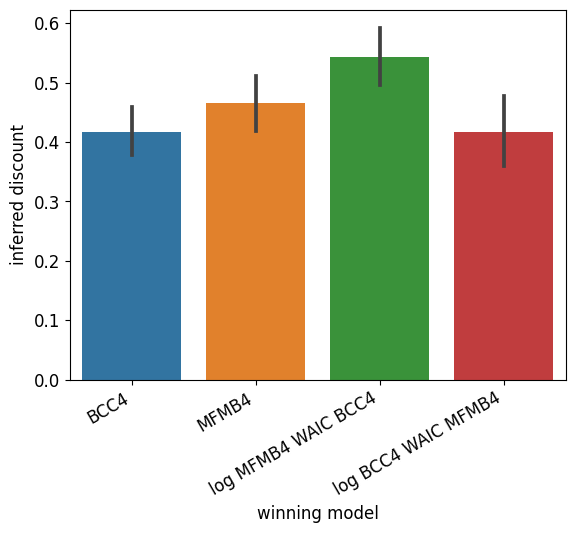

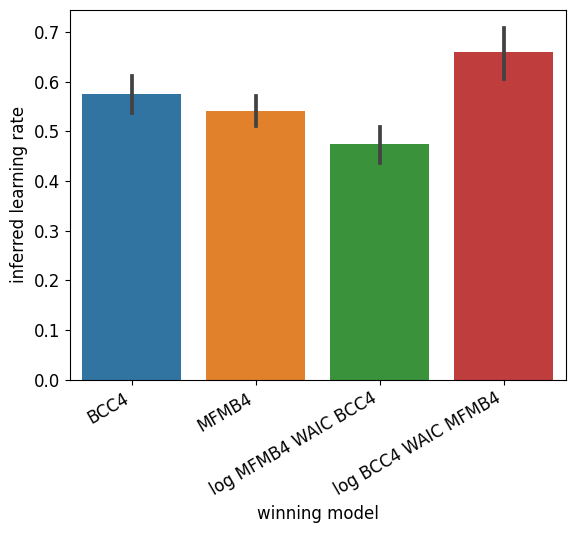

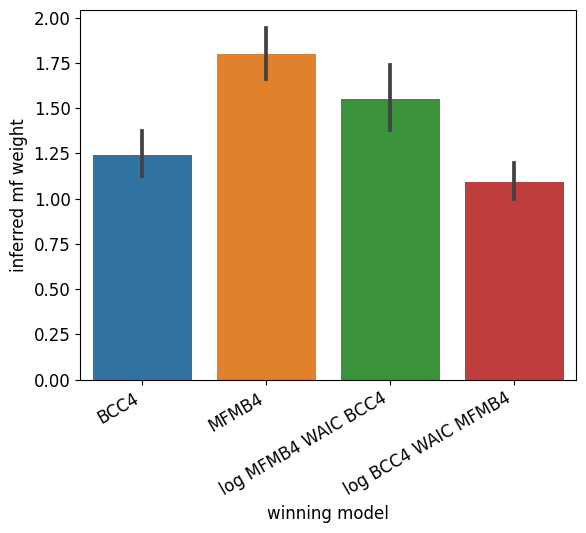

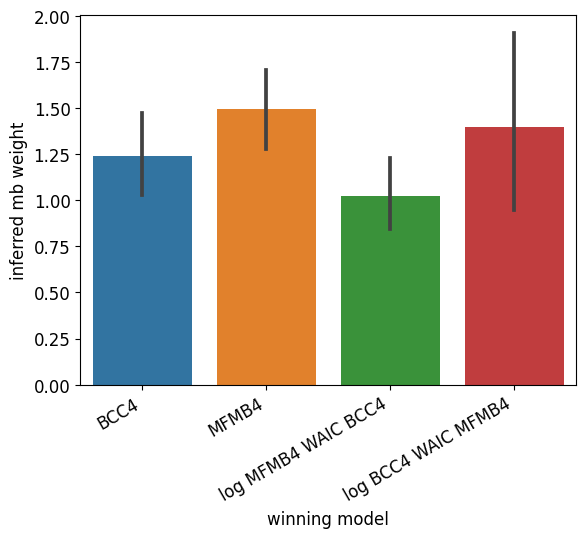

Ns tensor(50) tensor(62) tensor(38) tensor(15)


In [ ]:
plot_fontsize = 12

for param in MFMB4_param_names:
    plot_group_bars(results_mean_df, param, only_fitting=True, annotate_pvals=False)

print("Ns", group_surely_BCC4[did_fit].sum(), group_surely_MFMB4[did_fit].sum(), group_log_MFMB4_WAIC_BCC4[did_fit].sum(), group_log_BCC4_WAIC_MFMB4[did_fit].sum())

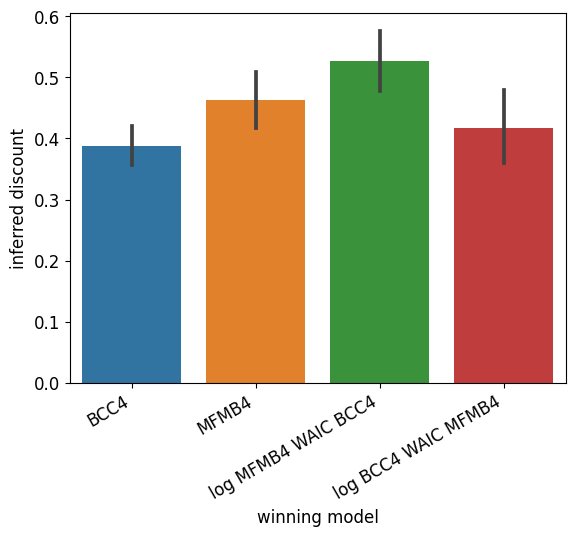

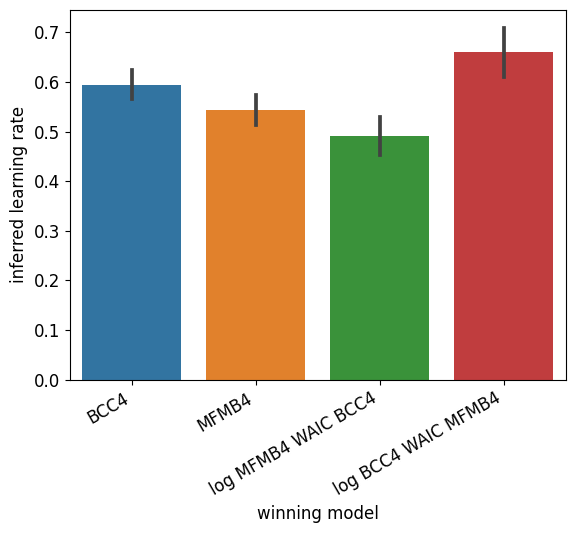

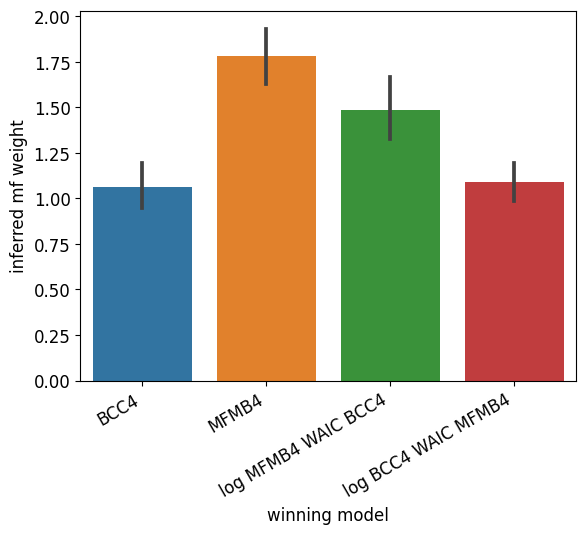

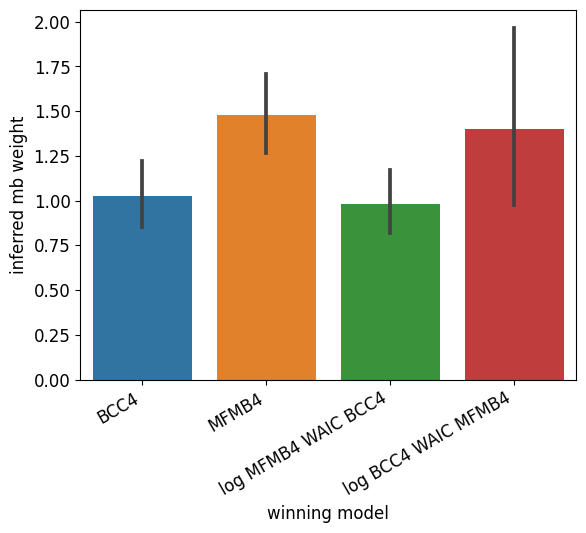

Ns tensor(69) tensor(63) tensor(41) tensor(15)


In [ ]:
for param in MFMB4_param_names:
    plot_group_bars(results_mean_df, param, only_fitting=False)

print("Ns", group_surely_BCC4.sum(), group_surely_MFMB4.sum(), group_log_MFMB4_WAIC_BCC4.sum(), group_log_BCC4_WAIC_MFMB4.sum())

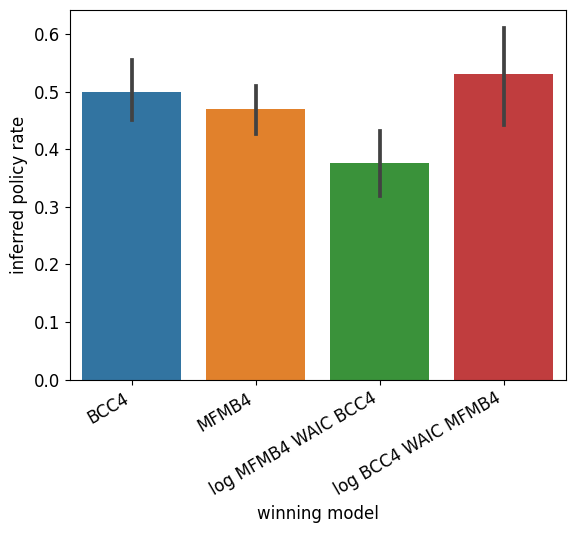

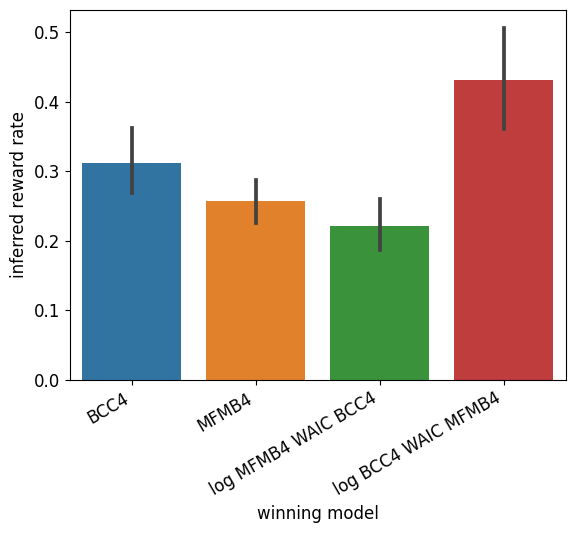

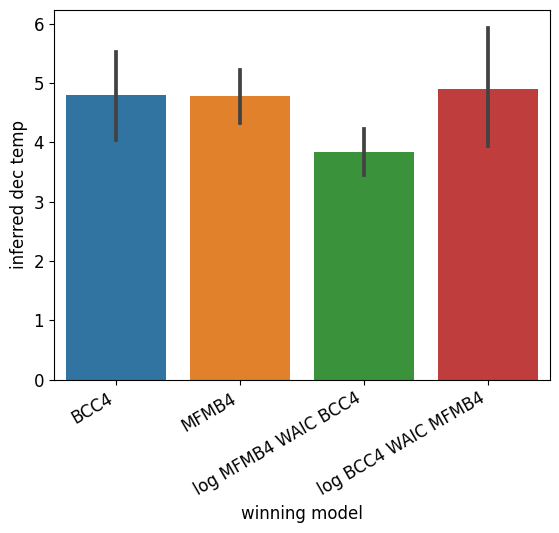

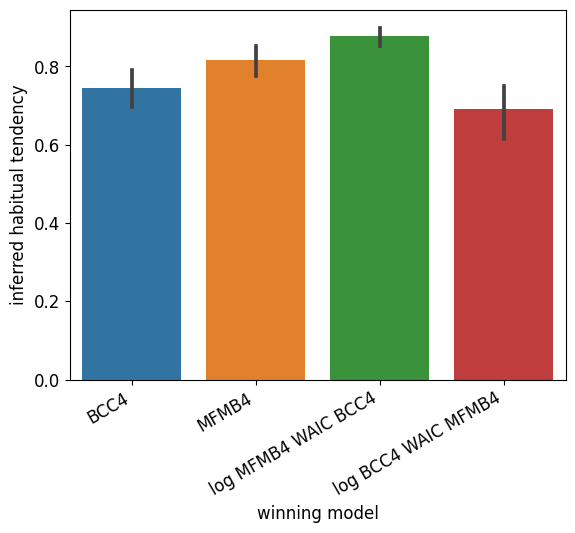

Ns tensor(50) tensor(62) tensor(38) tensor(15)


In [ ]:
for param in BCC4_param_names:
    plot_group_bars(results_mean_df, param, only_fitting=True)

print("Ns", group_surely_BCC4[did_fit].sum(), group_surely_MFMB4[did_fit].sum(), group_log_MFMB4_WAIC_BCC4[did_fit].sum(), group_log_BCC4_WAIC_MFMB4[did_fit].sum())

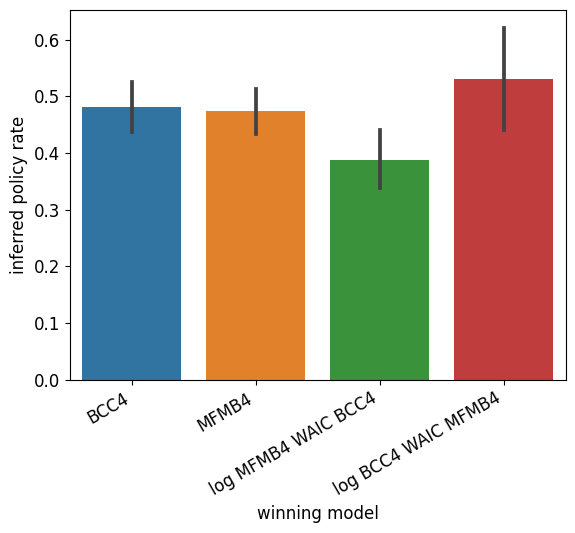

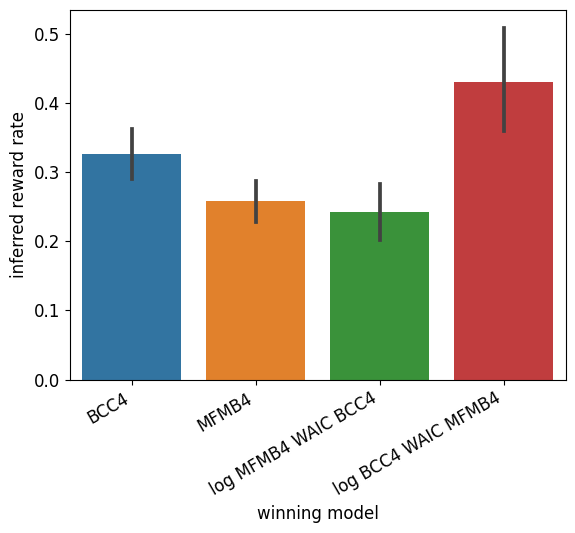

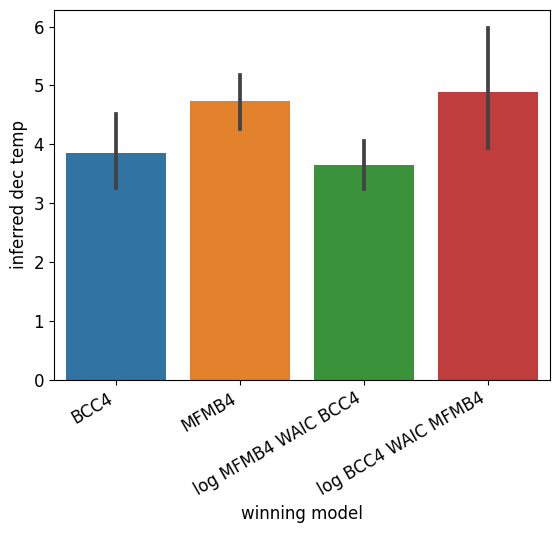

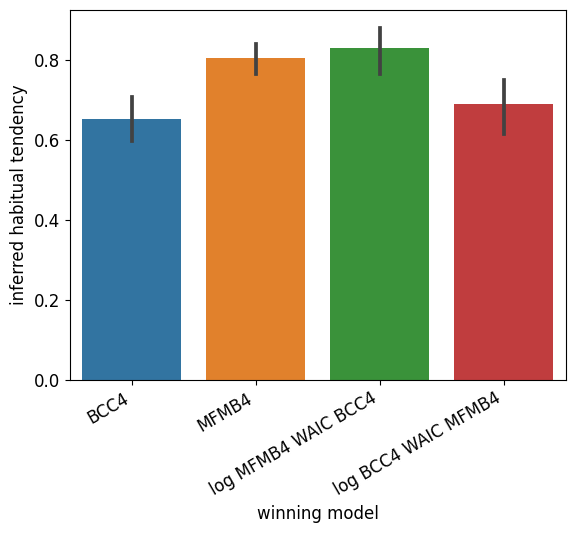

Ns tensor(69) tensor(63) tensor(41) tensor(15)


In [ ]:
for param in BCC4_param_names:
    plot_group_bars(results_mean_df, param, only_fitting=False, fontsize=plot_fontsize)

print("Ns", group_surely_BCC4.sum(), group_surely_MFMB4.sum(), group_log_MFMB4_WAIC_BCC4.sum(), group_log_BCC4_WAIC_MFMB4.sum())

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

MFMB4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:3.714e-02
MFMB4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:3.714e-02
log MFMB4 WAIC BCC4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:5.880e-03
log MFMB4 WAIC BCC4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:5.880e-03
BCC4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:4.650e-04
BCC4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:4.650e-04


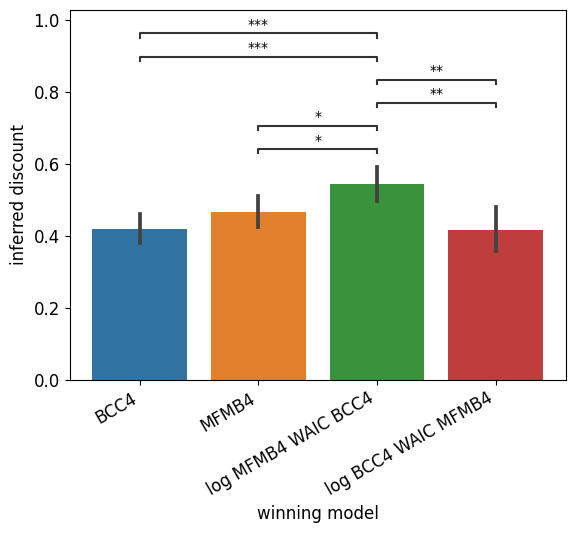

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

MFMB4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:1.135e-02
MFMB4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:1.135e-02
log MFMB4 WAIC BCC4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:1.751e-05
log MFMB4 WAIC BCC4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:1.751e-05
BCC4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:1.389e-03
MFMB4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:1.164e-03
BCC4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:1.389e-03
MFMB4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:1.164e-03
BCC4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:2.255e-02
BCC4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:2.255e-02


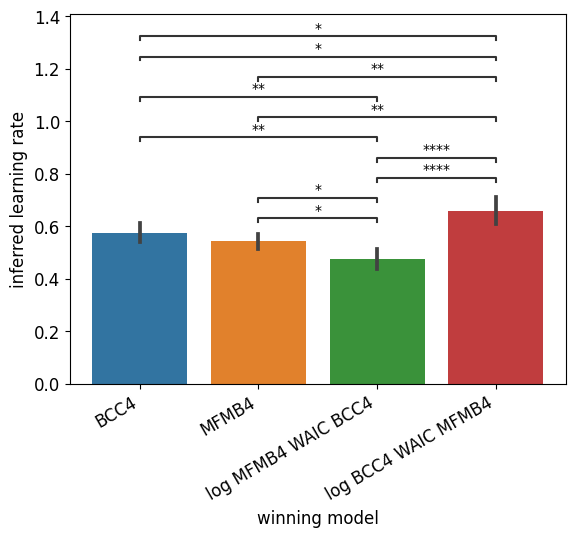

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

BCC4 vs. MFMB4: Custom statistical test, P_val:8.427e-07
BCC4 vs. MFMB4: Custom statistical test, P_val:8.427e-07
MFMB4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:3.403e-02
MFMB4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:3.403e-02
log MFMB4 WAIC BCC4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:1.637e-03
log MFMB4 WAIC BCC4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:1.637e-03
BCC4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:4.237e-03
MFMB4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:4.822e-06
BCC4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:4.237e-03
MFMB4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:4.822e-06


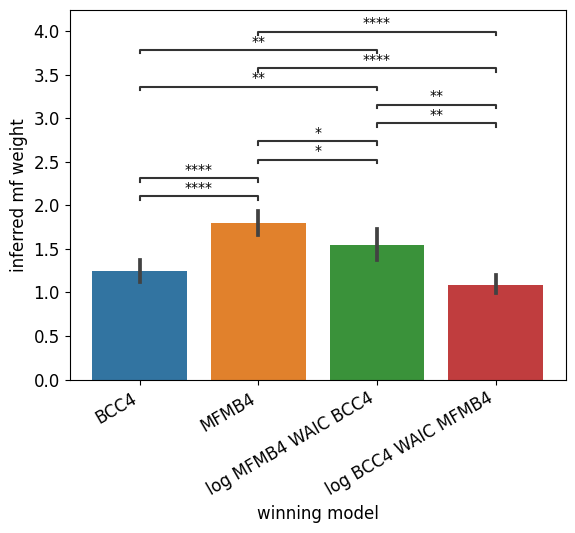

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

MFMB4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:7.039e-03
MFMB4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:7.039e-03


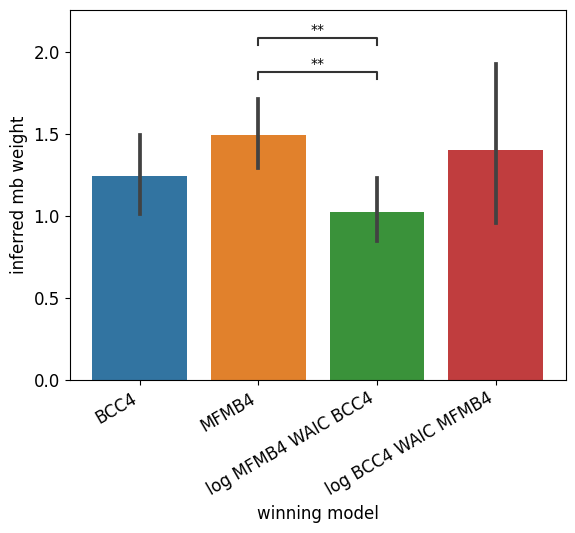

Ns tensor(50) tensor(62) tensor(38) tensor(15)


In [ ]:
plot_fontsize = 12

for param in MFMB4_param_names:
    plot_group_bars(results_mean_df, param, only_fitting=True, annotate_pvals=True)

print("Ns", group_surely_BCC4[did_fit].sum(), group_surely_MFMB4[did_fit].sum(), group_log_MFMB4_WAIC_BCC4[did_fit].sum(), group_log_BCC4_WAIC_MFMB4[did_fit].sum())

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

MFMB4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:3.714e-02
MFMB4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:3.714e-02
log MFMB4 WAIC BCC4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:5.880e-03
log MFMB4 WAIC BCC4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:5.880e-03
BCC4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:4.650e-04
BCC4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:4.650e-04


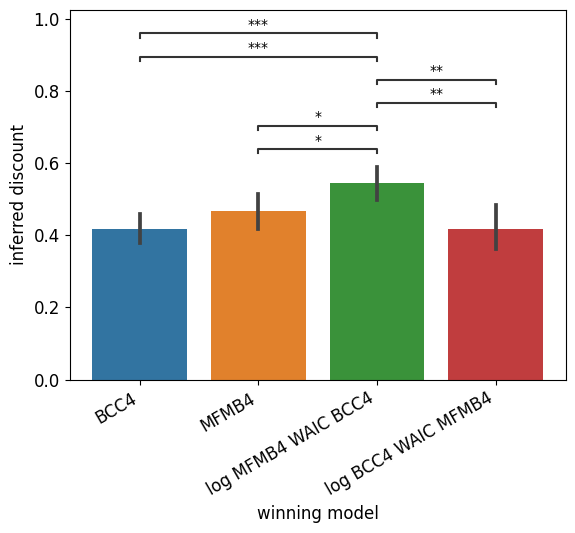

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

MFMB4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:1.135e-02
MFMB4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:1.135e-02
log MFMB4 WAIC BCC4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:1.751e-05
log MFMB4 WAIC BCC4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:1.751e-05
BCC4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:1.389e-03
MFMB4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:1.164e-03
BCC4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:1.389e-03
MFMB4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:1.164e-03
BCC4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:2.255e-02
BCC4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:2.255e-02


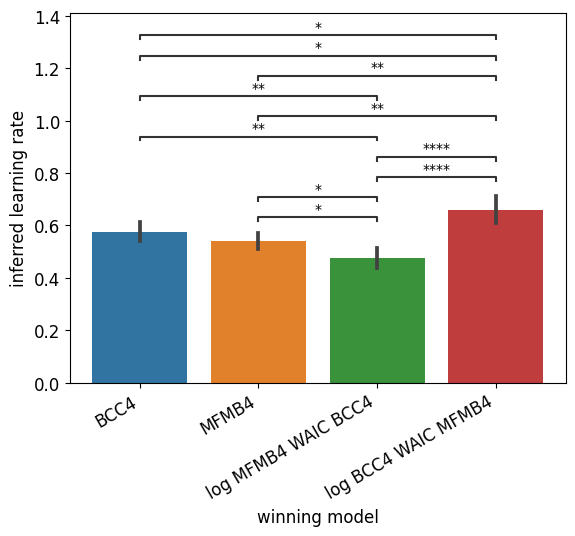

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

BCC4 vs. MFMB4: Custom statistical test, P_val:8.427e-07
BCC4 vs. MFMB4: Custom statistical test, P_val:8.427e-07
MFMB4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:3.403e-02
MFMB4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:3.403e-02
log MFMB4 WAIC BCC4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:1.637e-03
log MFMB4 WAIC BCC4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:1.637e-03
BCC4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:4.237e-03
MFMB4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:4.822e-06
BCC4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:4.237e-03
MFMB4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:4.822e-06


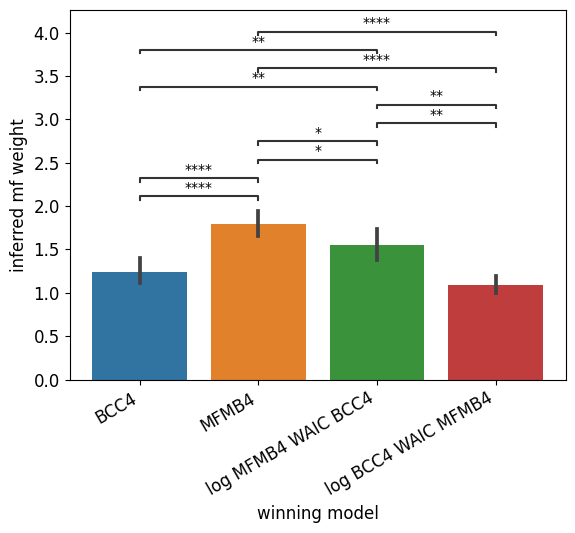

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

MFMB4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:7.039e-03
MFMB4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:7.039e-03


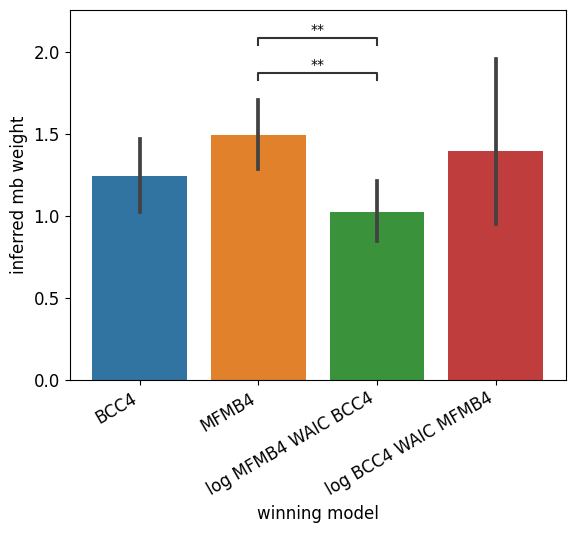

Ns tensor(50) tensor(62) tensor(38) tensor(15)


In [ ]:
plot_fontsize = 12

for param in MFMB4_param_names:
    plot_group_bars(results_mean_df, param, only_fitting=True, annotate_pvals=True)

print("Ns", group_surely_BCC4[did_fit].sum(), group_surely_MFMB4[did_fit].sum(), group_log_MFMB4_WAIC_BCC4[did_fit].sum(), group_log_BCC4_WAIC_MFMB4[did_fit].sum())

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

BCC4 vs. MFMB4: Custom statistical test, P_val:2.065e-02
BCC4 vs. MFMB4: Custom statistical test, P_val:2.065e-02
log MFMB4 WAIC BCC4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:1.700e-02
log MFMB4 WAIC BCC4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:1.700e-02
BCC4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:3.540e-05
BCC4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:3.540e-05


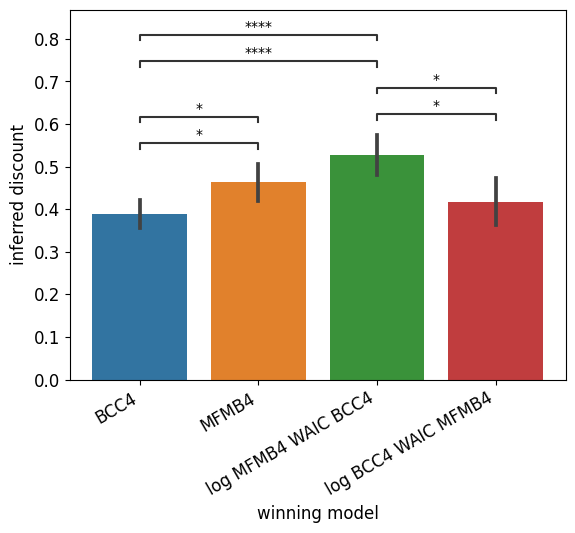

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

BCC4 vs. MFMB4: Custom statistical test, P_val:2.193e-02
BCC4 vs. MFMB4: Custom statistical test, P_val:2.193e-02
MFMB4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:4.386e-02
MFMB4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:4.386e-02
log MFMB4 WAIC BCC4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:8.767e-05
log MFMB4 WAIC BCC4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:8.767e-05
BCC4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:1.981e-04
MFMB4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:1.399e-03
BCC4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:1.981e-04
MFMB4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:1.399e-03


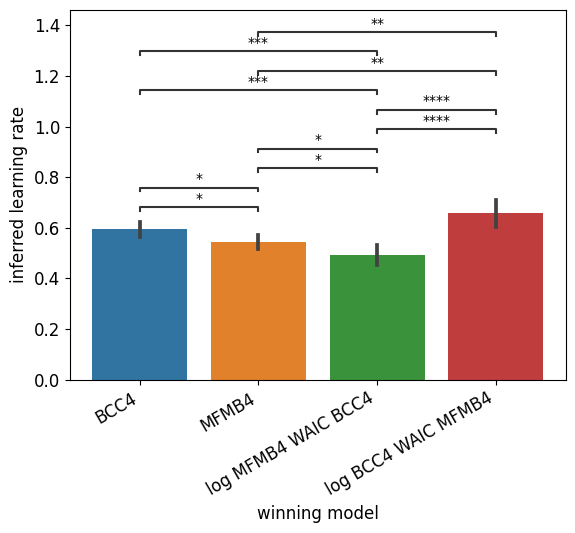

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

BCC4 vs. MFMB4: Custom statistical test, P_val:9.268e-11
BCC4 vs. MFMB4: Custom statistical test, P_val:9.268e-11
MFMB4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:1.310e-02
MFMB4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:1.310e-02
log MFMB4 WAIC BCC4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:1.067e-02
log MFMB4 WAIC BCC4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:1.067e-02
BCC4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:8.014e-05
MFMB4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:9.656e-06
BCC4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:8.014e-05
MFMB4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:9.656e-06


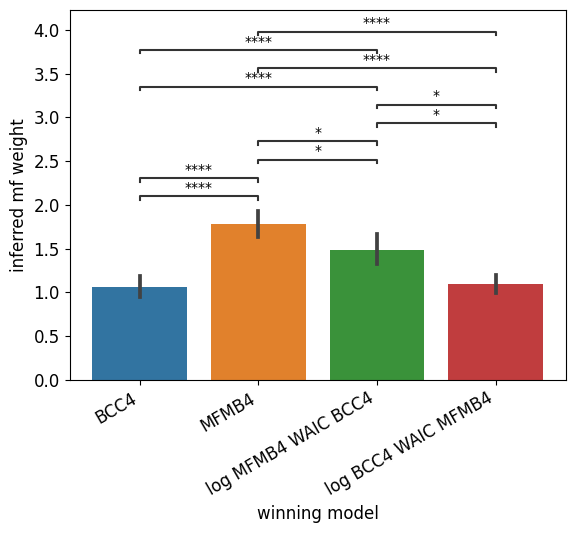

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

BCC4 vs. MFMB4: Custom statistical test, P_val:1.098e-04
BCC4 vs. MFMB4: Custom statistical test, P_val:1.098e-04
MFMB4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:2.265e-03
MFMB4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:2.265e-03
BCC4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:1.089e-02
BCC4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:1.089e-02


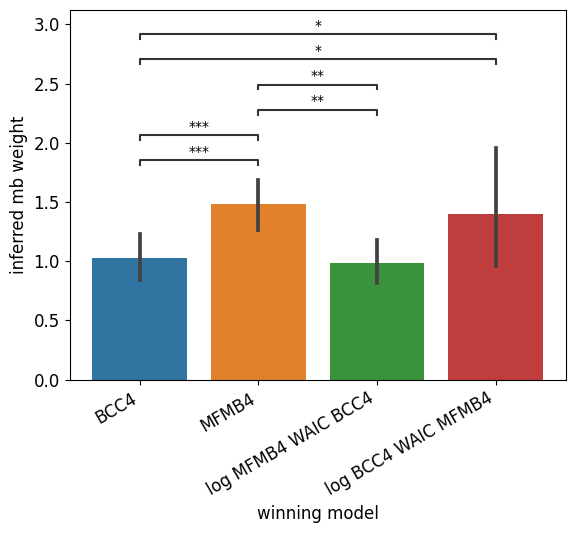

Ns tensor(69) tensor(63) tensor(41) tensor(15)


In [ ]:
for param in MFMB4_param_names:
    plot_group_bars(results_mean_df, param, only_fitting=False, annotate_pvals=True)

print("Ns", group_surely_BCC4.sum(), group_surely_MFMB4.sum(), group_log_MFMB4_WAIC_BCC4.sum(), group_log_BCC4_WAIC_MFMB4.sum())

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

MFMB4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:6.324e-03
MFMB4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:6.324e-03
log MFMB4 WAIC BCC4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:8.891e-03
log MFMB4 WAIC BCC4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:8.891e-03
BCC4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:3.419e-03
BCC4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:3.419e-03


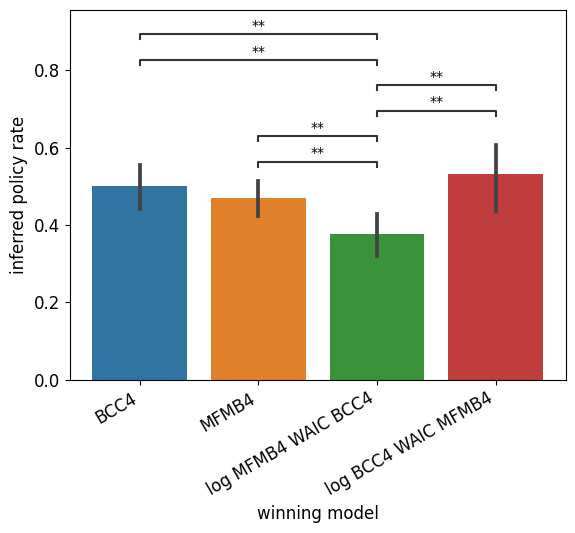

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

log MFMB4 WAIC BCC4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:8.178e-05
log MFMB4 WAIC BCC4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:8.178e-05
BCC4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:9.824e-03
MFMB4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:1.774e-04
BCC4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:9.824e-03
MFMB4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:1.774e-04
BCC4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:1.547e-02
BCC4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:1.547e-02


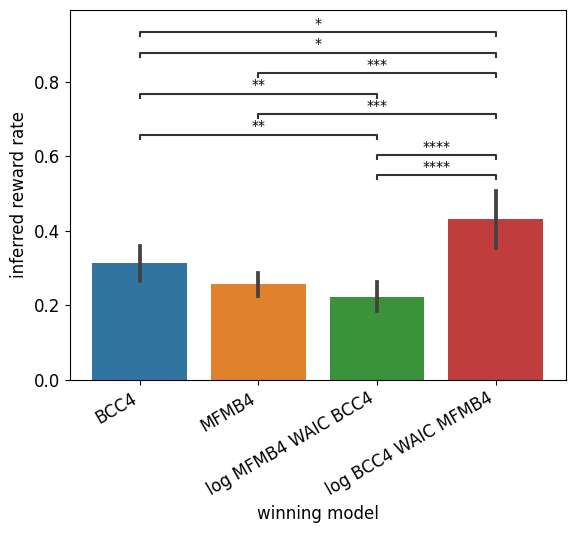

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

MFMB4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:7.993e-03
MFMB4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:7.993e-03


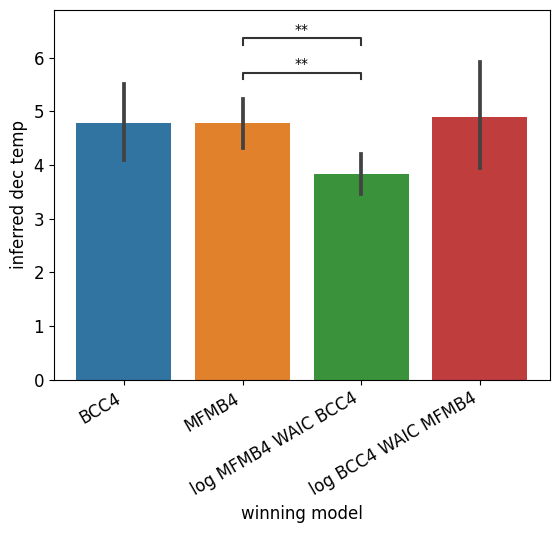

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

BCC4 vs. MFMB4: Custom statistical test, P_val:7.724e-04
BCC4 vs. MFMB4: Custom statistical test, P_val:7.724e-04
MFMB4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:2.235e-03
MFMB4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:2.235e-03
log MFMB4 WAIC BCC4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:5.032e-07
log MFMB4 WAIC BCC4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:5.032e-07
BCC4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:3.261e-09
MFMB4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:8.076e-05
BCC4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:3.261e-09
MFMB4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:8.076e-05
BCC4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:4.061e-02
BCC4 vs. log BCC4 WAI

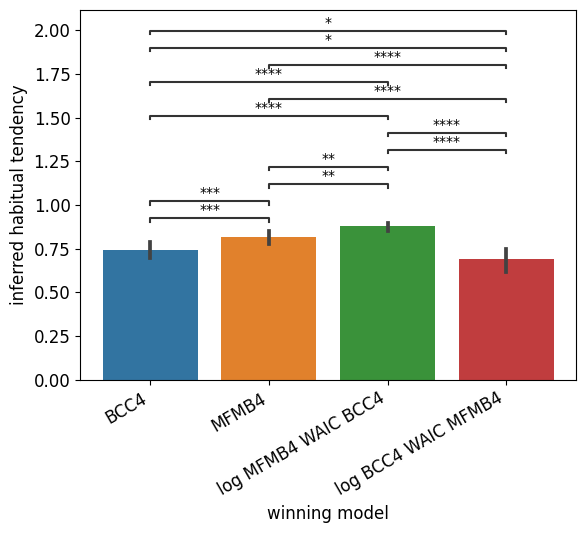

Ns tensor(50) tensor(62) tensor(38) tensor(15)


In [ ]:
for param in BCC4_param_names:
    plot_group_bars(results_mean_df, param, only_fitting=True, annotate_pvals=True)

print("Ns", group_surely_BCC4[did_fit].sum(), group_surely_MFMB4[did_fit].sum(), group_log_MFMB4_WAIC_BCC4[did_fit].sum(), group_log_BCC4_WAIC_MFMB4[did_fit].sum())

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

MFMB4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:1.170e-02
MFMB4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:1.170e-02
log MFMB4 WAIC BCC4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:1.460e-02
log MFMB4 WAIC BCC4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:1.460e-02
BCC4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:9.943e-03
BCC4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:9.943e-03


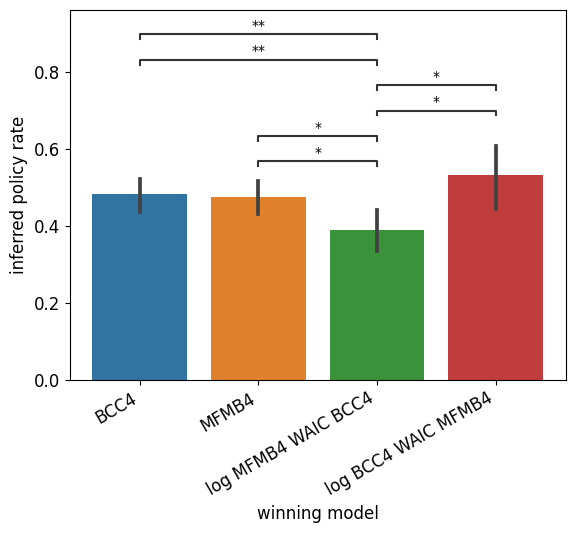

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

BCC4 vs. MFMB4: Custom statistical test, P_val:1.556e-02
BCC4 vs. MFMB4: Custom statistical test, P_val:1.556e-02
log MFMB4 WAIC BCC4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:4.392e-04
log MFMB4 WAIC BCC4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:4.392e-04
BCC4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:6.408e-03
MFMB4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:1.662e-04
BCC4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:6.408e-03
MFMB4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:1.662e-04
BCC4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:2.648e-02
BCC4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:2.648e-02


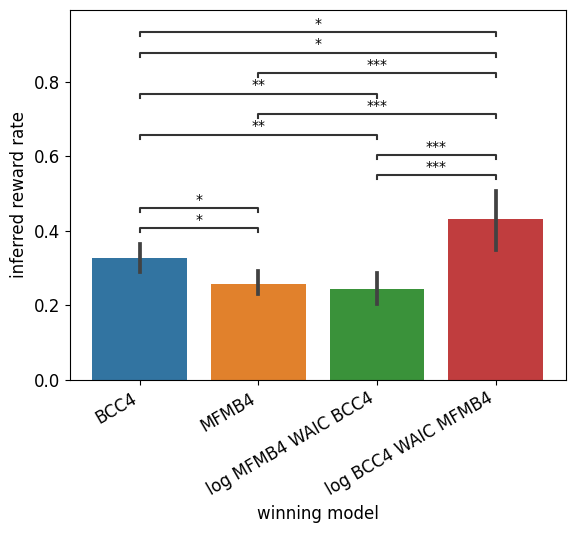

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

BCC4 vs. MFMB4: Custom statistical test, P_val:6.266e-03
BCC4 vs. MFMB4: Custom statistical test, P_val:6.266e-03
MFMB4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:3.010e-03
MFMB4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:3.010e-03
log MFMB4 WAIC BCC4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:2.902e-02
log MFMB4 WAIC BCC4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:2.902e-02


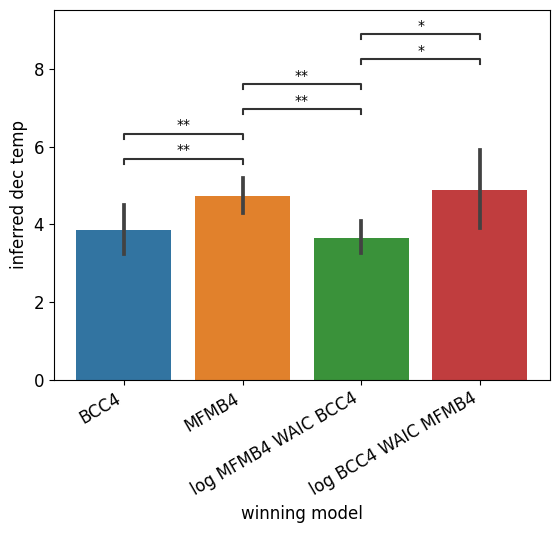

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

BCC4 vs. MFMB4: Custom statistical test, P_val:1.309e-06
BCC4 vs. MFMB4: Custom statistical test, P_val:1.309e-06
MFMB4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:1.788e-02
MFMB4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:1.788e-02
log MFMB4 WAIC BCC4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:1.626e-05
log MFMB4 WAIC BCC4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:1.626e-05
BCC4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:2.534e-09
MFMB4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:1.502e-04
BCC4 vs. log MFMB4 WAIC BCC4: Custom statistical test, P_val:2.534e-09
MFMB4 vs. log BCC4 WAIC MFMB4: Custom statistical test, P_val:1.502e-04


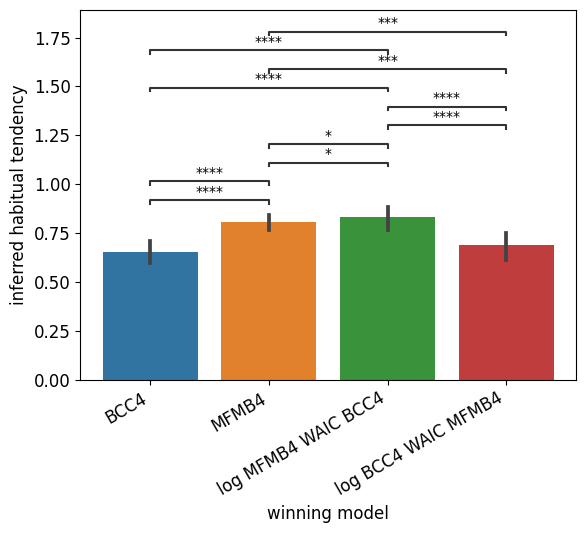

Ns tensor(69) tensor(63) tensor(41) tensor(15)


In [ ]:
for param in BCC4_param_names:
    plot_group_bars(results_mean_df, param, only_fitting=False, fontsize=plot_fontsize, annotate_pvals=True)

print("Ns", group_surely_BCC4.sum(), group_surely_MFMB4.sum(), group_log_MFMB4_WAIC_BCC4.sum(), group_log_BCC4_WAIC_MFMB4.sum())